# Data Preprocessing

**Importing the libraries**

In [ ]:
pip show pandas numpy scikit-learn xgboost lightgbm catboost shap scipy matplotlib seaborn imbalanced-learn category-encoders joblib kagglehub | grep -E "^(Name|Version)"

Name: pandas
Version: 2.2.2
Name: numpy
Version: 2.0.2
Name: lapack-lite
Name: dragon4
Name: libdivide
Name: Meson
Name: spin
Name: OpenBLAS
Name: LAPACK
Name: GCC runtime library
Version 3.1, 31 March 2009
Name: libquadmath
Name: scikit-learn
Version: 1.6.1
Name: xgboost
Version: 3.3.0
Name: lightgbm
Version: 4.6.0
Name: shap
Version: 0.52.0
Name: scipy
Version: 1.16.3
Name: matplotlib
Version: 3.10.0
Name: seaborn
Version: 0.13.2
Name: imbalanced-learn
Version: 0.14.2
Name: joblib
Version: 1.5.3
Name: kagglehub
Version: 1.0.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Importing the needs libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder, OneHotEncoder
import sys
import os
import importlib
import kagglehub
import math

In [ ]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [ ]:
csv_file_path = os.path.join(path, 'creditcard.csv')
Data = pd.read_csv(csv_file_path)
print(f"   ✓ Total data: {len(Data)} rows, {len(Data.columns)} columns")
print()

   ✓ Total data: 284807 rows, 31 columns



**1 Dataset Size (memory size, number of records and attributes, etc.)**

In [ ]:
Data.shape

(284807, 31)

**2 Direct visualization of the data (head)**

In [ ]:
print(Data.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [ ]:
Data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


# **3 Type of available attributes (numerical, categorical)**

In [ ]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# All types are numerical

**4 Descriptive statistics (mean values, dispersion, percentiles, etc.)**

In [ ]:
Data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**5 Number of null values**

In [ ]:
nulls = Data.isnull().sum()
columns_with_nulls = nulls[nulls > 0]

if len(columns_with_nulls) > 0:
    print("Columns with missing values:")
    for col, cant in columns_with_nulls.items():
        porc = (cant / len(Data)) * 100
        print(f"   {col}: {cant} missing ({porc:.1f}%)")
else:
    print("   ✓ There aren't nulls values")
print()

   ✓ There aren't nulls values



**6 Distribution / range of values of the target**


,count,percent
Class,,
0,284315,99.827
1,492,0.173


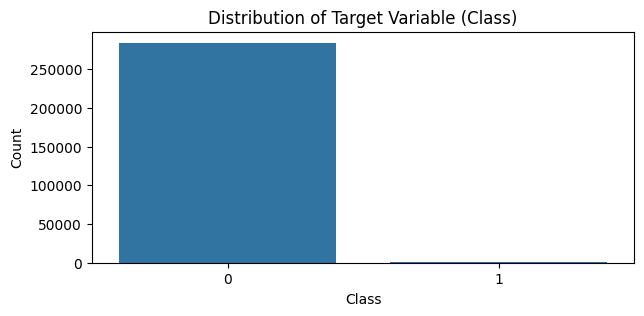

In [ ]:
target = Data['Class']
counts = target.value_counts(dropna=False)
perc = (counts / len(target) * 100).round(3)
summary_target_distribution = pd.DataFrame({"count": counts, "percent": perc})
display(summary_target_distribution)

plt.figure(figsize=(7, 3))
order = counts.index
sns.countplot(x=target, order=order)
plt.title("Distribution of Target Variable (Class)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

**7 Outlier identification**


📊 PART 1: OUTLIERS IN NUMERICAL VARIABLES

📦 CREATING BOXPLOTS FOR VISUAL OUTLIER DETECTION:

📊 ANALYZING: Time
----------------------------------------
Type: float64
Unique values: 124592
Null values: 0 (0.0%)

📊 Statistics:
  Minimum: 0.00
  Maximum: 172792.00
  Mean: 94813.86
  Median: 84692.00
  Standard Deviation: 47488.15

🔍 OUTLIERS (IQR method):
  Lower bound: -73477.00
  Upper bound: 266999.00
  Outliers found: 0 (0.0%)

💡 RECOMMENDATION:
  No outliers - keep data as is

📊 ANALYZING: V1
----------------------------------------
Type: float64
Unique values: 275663
Null values: 0 (0.0%)

📊 Statistics:
  Minimum: -56.41
  Maximum: 2.45
  Mean: 0.00
  Median: 0.02
  Standard Deviation: 1.96

🔍 OUTLIERS (IQR method):
  Lower bound: -4.27
  Upper bound: 4.67
  Outliers found: 7062 (2.5%)

💡 RECOMMENDATION:
  Some outliers (1-5%) - check for errors or transform

📊 ANALYZING: V2
----------------------------------------
Type: float64
Unique values: 275663
Null values: 0 (0.0%)

📊 Stati

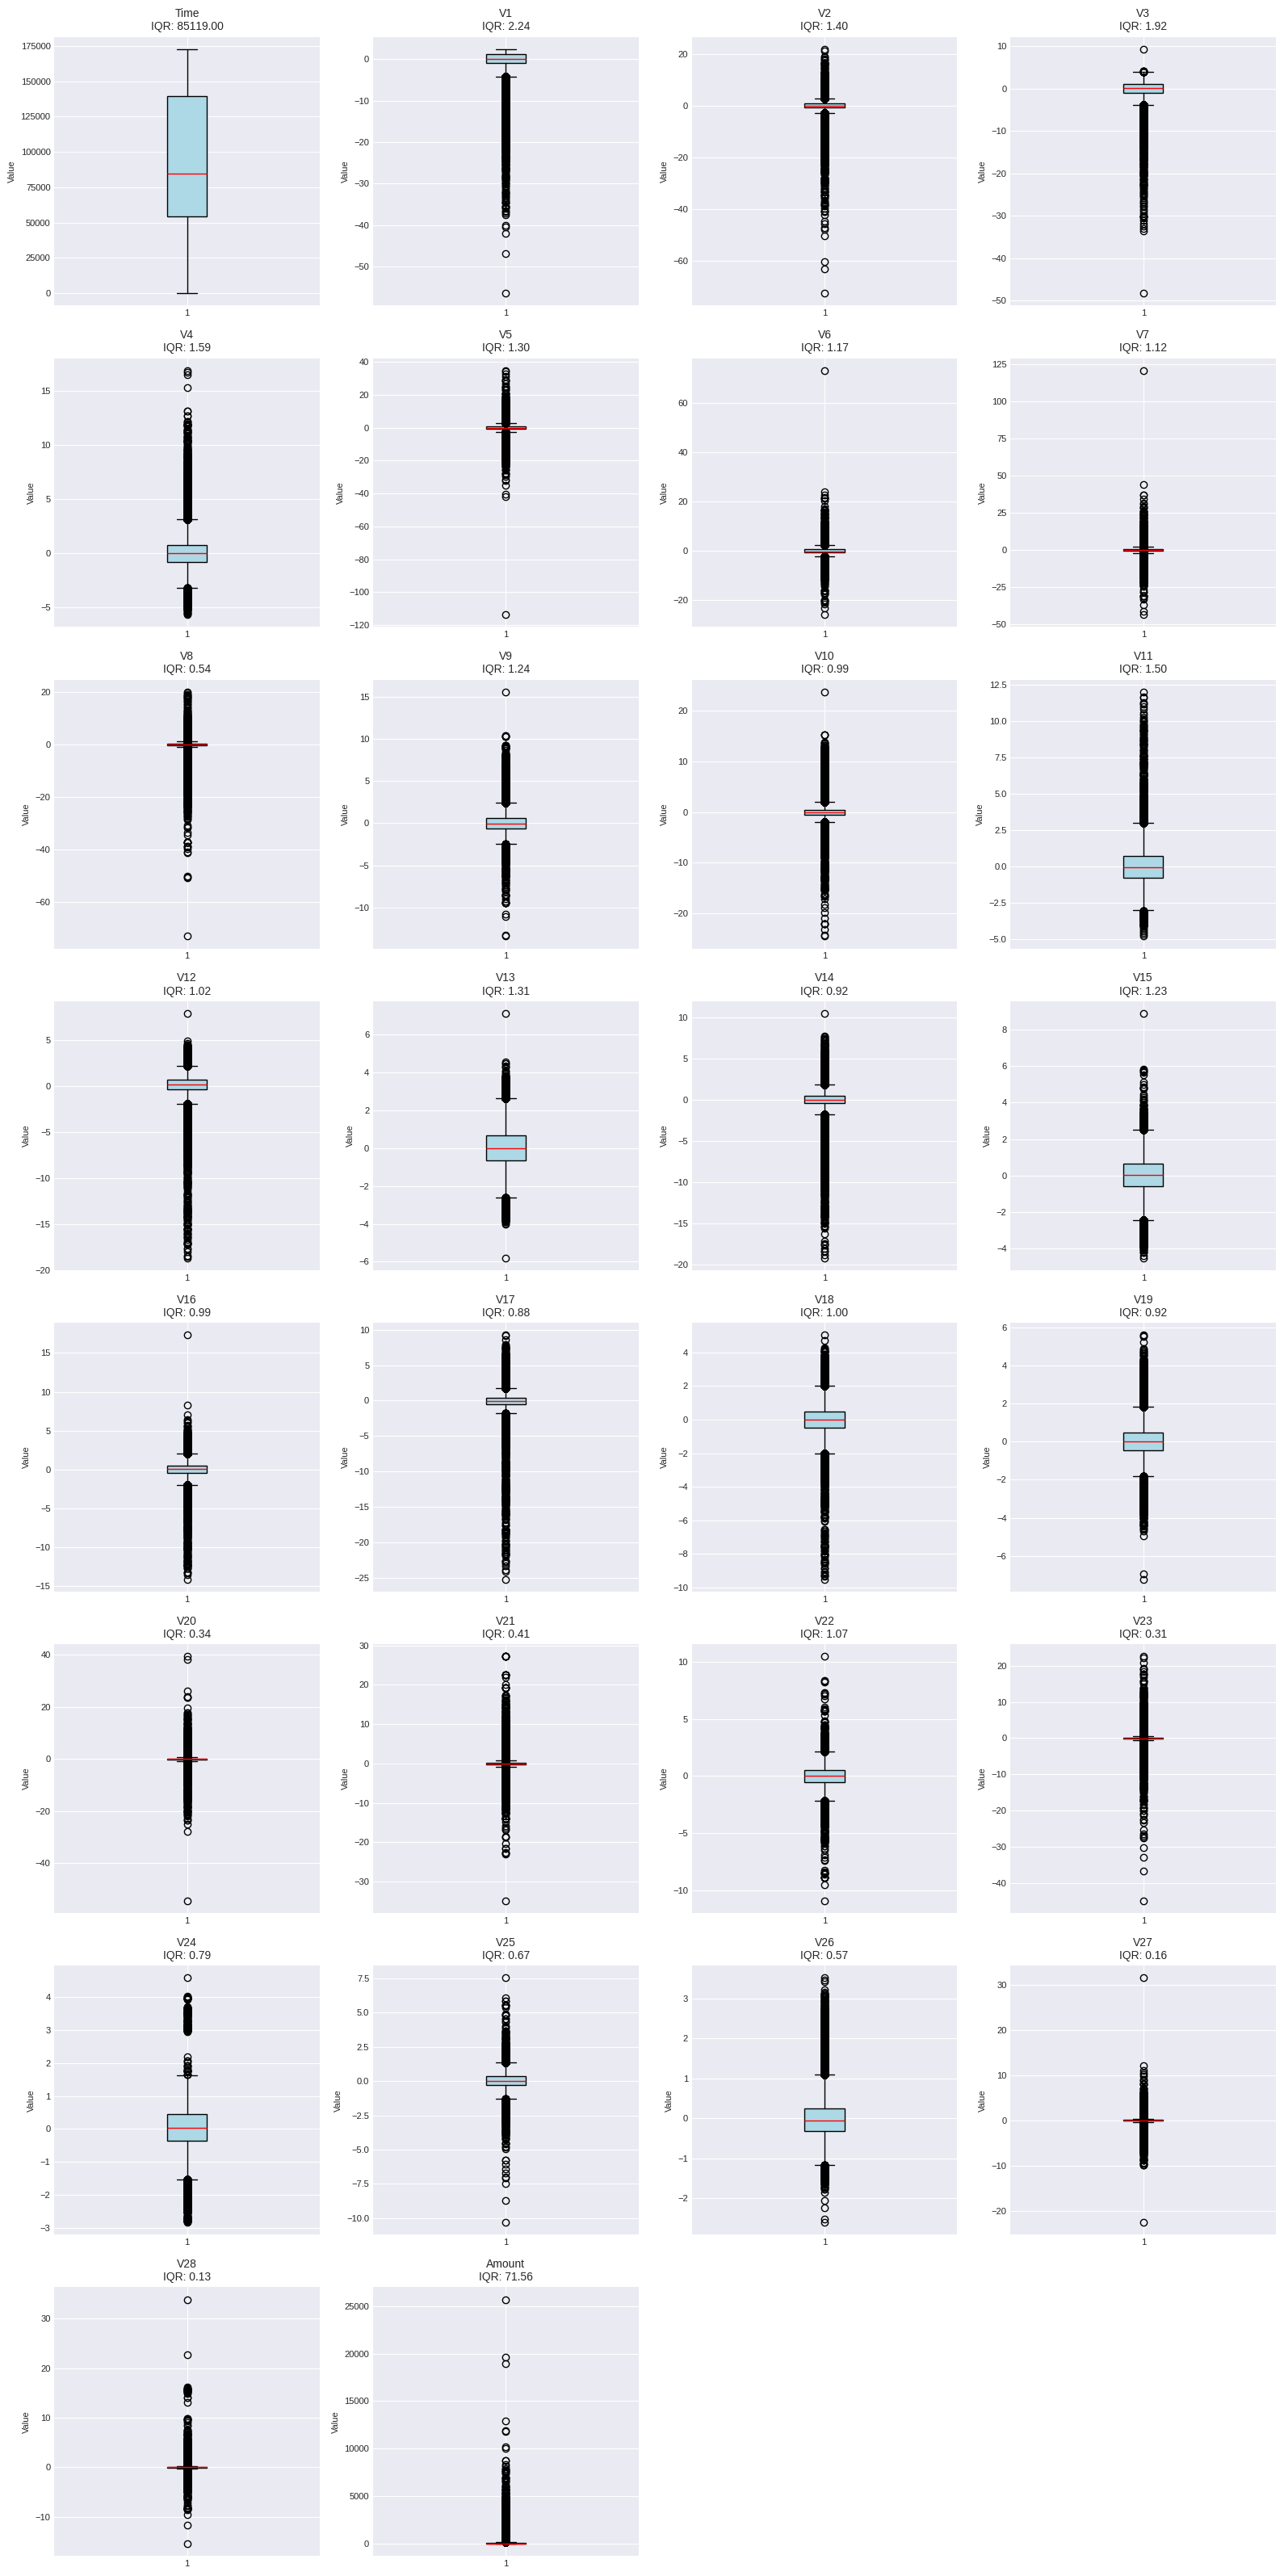

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# For this dataset, all features except 'Class' are important for outlier detection
all_columns = Data.columns.drop('Class').tolist()


print('\n' + '=' * 60)
print('📊 PART 1: OUTLIERS IN NUMERICAL VARIABLES')
print('=' * 60)

# All selected columns are numerical in this dataset
columnas_numericas = all_columns

# Function to analyze each numerical variable
def analyze_numerical_variable(df, column):
    """
    Analyzes a numerical variable and detects outliers
    """
    print(f"\n📊 ANALYZING: {column}") # Added this line to print the column name
    print('-' * 40)

    # Basic Statistics
    print(f"Type: {df[column].dtype}")
    print(f"Unique values: {df[column].nunique()}")
    print(f"Null values: {df[column].isnull().sum()} ({df[column].isnull().sum()/len(df)*100:.1f}%)")

    # Descriptive Statistics
    stats = df[column].describe()
    print(f"\n📊 Statistics:")
    print(f"  Minimum: {stats['min']:.2f}")
    print(f"  Maximum: {stats['max']:.2f}")
    print(f"  Mean: {stats['mean']:.2f}")
    print(f"  Median: {stats['50%']:.2f}")
    print(f"  Standard Deviation: {stats['std']:.2f}")

    # Detect outliers using IQR method
    Q1 = stats['25%']
    Q3 = stats['75%']
    IQR = Q3 - Q1

    if IQR > 0:  # Avoid division by zero
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count outliers
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        num_outliers = len(outliers)
        percentage = (num_outliers / len(df)) * 100

        print(f"\n🔍 OUTLIERS (IQR method):")
        print(f"  Lower bound: {lower_bound:.2f}")
        print(f"  Upper bound: {upper_bound:.2f}")
        print(f"  Outliers found: {num_outliers} ({percentage:.1f}%)")

        # Recommendation based on outlier percentage
        print(f"\n💡 RECOMMENDATION:")
        if num_outliers == 0:
            print("  No outliers - keep data as is")
        elif percentage < 1:
            print("  Few outliers (<1%) - consider removing them or Winsorization")
        elif percentage < 5:
            print("  Some outliers (1-5%) - check for errors or transform")
        else:
            print("  Many outliers (>5%) - likely natural distribution or robust features")

    return Q1, Q3, IQR

# Create boxplots for all numerical variables
print("\n📦 CREATING BOXPLOTS FOR VISUAL OUTLIER DETECTION:")

# Determine grid size for subplots
num_cols_to_plot = len(columnas_numericas)
subplot_cols = 4  # Number of columns in the subplot grid
subplot_rows = math.ceil(num_cols_to_plot / subplot_cols)

fig, axes = plt.subplots(subplot_rows, subplot_cols, figsize=(4 * subplot_cols, 4 * subplot_rows)) # Dynamic figure size
axes = axes.flatten()

for idx, col in enumerate(columnas_numericas):
    # Boxplot
    bp = axes[idx].boxplot(Data[col].dropna(), patch_artist=True, vert=True)

    # Color
    bp['boxes'][0].set_facecolor('lightblue')
    bp['medians'][0].set_color('red')

    # Add info
    Q1, Q3, IQR = analyze_numerical_variable(Data, col)
    axes[idx].set_title(f'{col}\nIQR: {IQR:.2f}', fontsize=10) # Adjusted font size
    axes[idx].set_ylabel('Value', fontsize=8)
    axes[idx].tick_params(axis='x', labelsize=8)
    axes[idx].tick_params(axis='y', labelsize=8)

# Hide empty subplots if any
for idx in range(num_cols_to_plot, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Absolute Extreme Values for 'Time' and 'Amount'

We will extract the 10 highest and 10 lowest values for "Time" and "Amount" along with all other features, without applying any outlier detection criteria. This provides a direct view of the most extreme values present in each column.

### Absolute Extreme Values for 'Time'

In [ ]:
# Top 10 lowest values for 'Time'
print("\nTop 10 lowest values for 'Time':")
display(Data.sort_values(by='Time', ascending=True).head(10))


Top 10 lowest values for 'Time':


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [ ]:
# Top 10 highest values for 'Time'
print("\nTop 10 highest values for 'Time':")
display(Data.sort_values(by='Time', ascending=False).head(10))


Top 10 highest values for 'Time':


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284801,172785.0,0.120316,0.931005,-0.546012,-0.745097,1.130314,-0.235973,0.812722,0.115093,-0.204064,...,-0.314205,-0.808520,0.050343,0.102800,-0.435870,0.124079,0.217940,0.068803,2.69,0
284800,172784.0,2.039560,-0.175233,-1.196825,0.234580,-0.008713,-0.726571,0.017050,-0.118228,0.435402,...,-0.268048,-0.717211,0.297930,-0.359769,-0.315610,0.201114,-0.080826,-0.075071,2.68,0
284799,172783.0,-1.775135,-0.004235,1.189786,0.331096,1.196063,5.519980,-1.518185,2.080825,1.159498,...,0.103302,0.654850,-0.348929,0.745323,0.704545,-0.127579,0.454379,0.130308,79.99,0
284797,172782.0,-0.241923,0.712247,0.399806,-0.463406,0.244531,-1.343668,0.929369,-0.206210,0.106234,...,-0.228876,-0.514376,0.279598,0.371441,-0.559238,0.113144,0.131507,0.081265,5.49,0
284798,172782.0,0.219529,0.881246,-0.635891,0.960928,-0.152971,-1.014307,0.427126,0.121340,-0.285670,...,0.099936,0.337120,0.251791,0.057688,-1.508368,0.144023,0.181205,0.215243,24.05,0


### Absolute Extreme Values for 'Amount'

In [ ]:
# Top 10 lowest values for 'Amount'
print("\nTop 10 lowest values for 'Amount':")
display(Data.sort_values(by='Amount', ascending=True).head(10))


Top 10 lowest values for 'Amount':


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
16898,28272.0,-1.068810,-0.310282,2.631675,2.028191,0.967845,-0.259903,-0.177717,-0.179516,0.583884,...,0.033184,0.788621,-0.375331,0.450686,-0.580746,-0.133729,-0.112478,-0.306113,0.0,0
16918,28292.0,1.050879,0.053408,1.364590,2.666158,-0.378636,1.382032,-0.766202,0.486126,0.152611,...,0.083467,0.624424,-0.157228,-0.240411,0.573061,0.244090,0.063834,0.010981,0.0,0
181496,124998.0,2.226874,0.129978,-2.990415,0.161708,1.411952,-0.726787,0.855592,-0.424791,0.087612,...,0.178635,0.635775,-0.259179,-0.308114,0.794287,0.764809,-0.134218,-0.100814,0.0,0
16799,28167.0,1.262545,0.010916,0.279802,-0.116729,-0.405100,-0.729799,-0.052636,-0.092520,0.250221,...,-0.208921,-0.574592,0.147313,0.120030,0.088564,0.877803,-0.072421,-0.000333,0.0,0
242234,151405.0,1.942927,0.232623,-0.238838,3.602384,0.266498,1.028408,-0.597185,0.265057,-0.167013,...,0.141610,0.484836,0.110395,-0.000660,-0.075677,0.086046,0.004475,-0.035761,0.0,0
242261,151415.0,-1.624698,0.611314,2.394833,4.597140,1.245290,0.557947,-0.494394,0.212051,-1.827552,...,-0.420608,-0.952776,-0.395335,-0.042494,-0.257313,0.022158,-0.120621,0.150415,0.0,0
118690,75176.0,1.235603,0.041383,0.675286,0.836279,-0.675016,-0.657342,-0.154209,-0.067491,0.602617,...,-0.308487,-0.728413,0.088164,0.396205,0.324557,0.182930,-0.017115,0.014979,0.0,0
230216,146239.0,1.899345,0.323415,0.046089,3.740338,0.050781,0.692388,-0.514474,0.166729,-0.364746,...,0.194738,0.684381,0.175958,0.657773,-0.125144,0.043587,0.011975,-0.027184,0.0,0
230364,146303.0,1.876265,0.284725,0.216620,3.862805,-0.252793,0.314930,-0.507905,0.124473,-0.273493,...,0.203360,0.728960,0.159552,-0.102247,-0.184301,0.081703,0.016591,-0.035473,0.0,0
280392,169503.0,1.859815,0.240076,0.135749,3.695264,-0.100237,0.698748,-0.598056,0.258713,-0.522487,...,0.233399,0.776202,0.108961,-0.353020,-0.164330,0.074389,0.009614,-0.047505,0.0,0


In [ ]:
# Top 10 highest values for 'Amount'
print("\nTop 10 highest values for 'Amount':")
display(Data.sort_values(by='Amount', ascending=False).head(10))


Top 10 highest values for 'Amount':


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
274771,166198.0,-35.548539,-31.850484,-48.325589,15.304184,-113.743307,73.301626,120.589494,-27.347360,-3.872425,...,-21.620120,5.712303,-1.581098,4.584549,4.554683,3.415636,31.612198,-15.430084,25691.16,0
58465,48401.0,-36.802320,-63.344698,-20.645794,16.715537,-20.672064,7.694002,24.956587,-4.730111,-2.687312,...,11.455313,-10.933144,-17.173665,1.180700,-7.025783,-2.534330,-3.602479,3.450224,19656.53,0
151296,95286.0,-34.549296,-60.464618,-21.340854,16.875344,-19.229075,6.335259,24.422716,-4.964566,0.188912,...,11.502580,-9.499423,-16.513186,0.744341,-7.081325,-2.604551,-3.550963,3.250802,18910.00,0
46841,42951.0,-23.712839,-42.172688,-13.320825,9.925019,-13.945538,5.564891,15.710644,-2.844253,-1.580725,...,7.921600,-6.320710,-11.310338,0.404175,-4.547278,-1.577118,-2.357385,2.253662,12910.93,0
54018,46253.0,-21.780665,-38.305310,-12.122469,9.752791,-12.880794,4.256017,14.785051,-2.818253,-0.667338,...,7.437478,-5.619439,-10.547038,0.653249,-4.232409,-0.480459,-2.257913,2.082488,11898.09,0
169457,119713.0,-20.924897,-37.943452,-14.060281,10.473005,-10.866639,6.256654,14.960521,-2.392155,-0.597076,...,6.829810,-6.926353,-9.928657,-0.447084,-4.848151,-2.241620,-2.140723,2.001492,11789.84,0
284249,172273.0,-9.030538,-11.112584,-16.233798,3.592021,-40.427726,23.917837,44.054461,-7.277778,-4.210637,...,-0.269048,0.988144,7.040028,0.347693,2.520869,2.342495,3.478175,-2.713136,10199.44,0
227921,145283.0,-21.532478,-34.704768,-8.303035,10.264175,3.957175,-3.229695,-4.066768,-4.083971,0.554072,...,5.198718,-7.331078,-32.828995,0.118986,-8.696627,-1.778061,-0.519786,2.716716,10000.00,0
74699,55709.0,-16.950064,-16.417395,-12.523381,6.555638,-27.752964,18.072031,28.504065,-10.152220,2.124673,...,-5.932594,0.050097,-10.855949,1.550407,-0.502172,0.821714,12.152401,-4.009839,8790.26,0
245474,152763.0,-14.641710,-28.554825,-12.714462,5.878264,-7.855074,2.471004,11.922577,-2.651203,-2.223985,...,5.788207,-3.269671,-8.024556,0.423021,-2.396701,-0.633380,-1.763704,1.422017,8787.00,0


### Why Isolation Forest instead of IQR for outlier detection

We chose **Isolation Forest** over the classic **IQR (Interquartile Range)** method for this dataset for several reasons:

- **Multivariate vs. univariate**: IQR is a univariate method — it checks each feature (V1, V2, ..., V28, Amount) separately, one column at a time. This dataset has 30 numerical features, so a transaction could look perfectly normal in every single feature individually, but still be anomalous when you look at the *combination* of features together. Isolation Forest evaluates all features jointly, so it can catch these multivariate anomalies that IQR would simply miss.

- **No distribution assumptions**: IQR assumes a roughly symmetric, unimodal distribution to define "normal" bounds (Q1 - 1.5*IQR, Q3 + 1.5*IQR). Many of the V1-V28 features (PCA components) are not perfectly normal or symmetric, so IQR thresholds can be unreliable or arbitrary here.

- **Too many false positives with 30 features**: If we apply IQR separately to 30 columns, the chance that a normal transaction gets flagged as an outlier in *at least one* column becomes very high (multiple testing problem). This would flag a huge portion of the dataset as "outliers," most of which are legitimate transactions with just one slightly extreme feature.

- **Conceptual fit with fraud**: Isolation Forest works by randomly partitioning the data and measuring how many splits it takes to isolate a point — anomalies (rare and different) get isolated in very few splits. This matches the nature of fraud almost exactly: fraudulent transactions are rare (~0.17%) and structurally different from normal ones, which is precisely the assumption Isolation Forest is built on.

- **Scalability**: Isolation Forest is efficient on large datasets (284,807 rows here) since it doesn't require distance or density calculations like other outlier methods (e.g., LOF), keeping training fast.

In short, IQR is a simple, interpretable starting point for single-feature sanity checks, but Isolation Forest is better suited as the actual outlier/anomaly detection method here because it captures the joint, multivariate nature of the data — which matches how fraud actually manifests.

## 2. Isolation Forest for Outlier Detection

Isolation Forest is an unsupervised anomaly detection algorithm that works by isolating anomalies in the data. It's particularly effective for high-dimensional datasets and does not assume any distribution for the data.

We will apply Isolation Forest to the numerical features (excluding 'Class') to identify potential outliers. The `contamination` parameter will be set to `0.01` (1%), representing the expected proportion of outliers in the dataset. This value can be tuned based on domain knowledge or further analysis.

After fitting the model, we will add a new column `is_outlier_IF` to the DataFrame, where `-1` indicates an outlier and `1` indicates an inlier. We will then display the count and percentage of outliers detected by this method.

In [ ]:
from sklearn.ensemble import IsolationForest

# Define features for Isolation Forest (all columns except 'Class')
features_for_if = Data.columns.drop('Class').tolist()

# Initialize and fit Isolation Forest model
# n_estimators: number of trees in the forest
# contamination: proportion of outliers in the data set (adjust based on domain knowledge)
# random_state: for reproducibility
isolation_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
Data['is_outlier_IF'] = isolation_forest.fit_predict(Data[features_for_if])

# Display the count and percentage of outliers detected by Isolation Forest
outlier_counts_if = Data['is_outlier_IF'].value_counts()
outlier_percentage_if = Data['is_outlier_IF'].value_counts(normalize=True) * 100

print("\n" + "=" * 60)
print("🌲 ISOLATION FOREST OUTLIER DETECTION RESULTS")
print("=" * 60)
print("\nOutlier counts (1 = inlier, -1 = outlier):")
print(outlier_counts_if)

print("\nOutlier percentage:")
print(outlier_percentage_if.round(2))

# Display some of the detected outliers
print("\nFirst 5 rows identified as outliers by Isolation Forest:")
display(Data[Data['is_outlier_IF'] == -1].head())


🌲 ISOLATION FOREST OUTLIER DETECTION RESULTS

Outlier counts (1 = inlier, -1 = outlier):
is_outlier_IF
 1    281958
-1      2849
Name: count, dtype: int64

Outlier percentage:
is_outlier_IF
 1    99.0
-1     1.0
Name: proportion, dtype: float64

First 5 rows identified as outliers by Isolation Forest:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,is_outlier_IF
164,103.0,-6.093248,-12.114213,-5.694973,3.294389,-1.413792,4.776000,4.808426,-0.228197,-0.525896,...,-2.264037,-3.553381,1.215279,-0.406073,-0.653384,-0.711222,0.672900,3828.04,0,-1
362,266.0,-2.564961,2.470985,2.649417,-1.564256,1.794297,-0.614742,4.185906,-3.855359,5.436633,...,-0.463149,-0.532466,0.306494,0.226844,-0.365416,-0.936735,-2.733887,10.35,0,-1
401,290.0,-5.166299,-5.449369,2.988498,2.658991,1.948152,-0.854470,-0.326394,-1.017364,1.983901,...,1.172278,3.150413,0.574081,1.018394,0.987099,0.658283,-1.609716,85.00,0,-1
455,333.0,-2.977214,0.781748,2.881724,-1.627798,-1.368067,1.656876,-1.185053,-5.393736,1.719407,...,-1.929181,0.190843,0.533134,0.296773,0.890104,-0.123225,-0.543750,75.00,0,-1
601,454.0,-3.133891,2.887394,2.178690,-1.576535,1.434510,-0.687313,3.816056,-3.416915,5.459274,...,-0.498518,-0.476668,0.302196,0.299993,-0.359155,-0.958818,-2.735623,9.65,0,-1


In [ ]:
# Cross-tabulation: Isolation Forest outliers vs real Class
crosstab = pd.crosstab(Data['is_outlier_IF'], Data['Class'],
                        rownames=['Isolation Forest'], colnames=['Class Real'])
print("Cross-tabulation (Isolation Forest vs Real Class):")
print(crosstab)

# Percentages
frauds_total = (Data['Class'] == 1).sum()
frauds_caught_as_outliers = ((Data['Class'] == 1) & (Data['is_outlier_IF'] == -1)).sum()
outliers_total = (Data['is_outlier_IF'] == -1).sum()

recall_fraud = frauds_caught_as_outliers / frauds_total
fraud_rate_in_outliers = frauds_caught_as_outliers / outliers_total
fraud_rate_overall = frauds_total / len(Data)
enrichment_factor = fraud_rate_in_outliers / fraud_rate_overall

print(f"\n% of real frauds detected as outliers (recall): {recall_fraud:.2%}")
print(f"% of fraud within detected outliers: {fraud_rate_in_outliers:.2%}")
print(f"% of fraud overall (baseline): {fraud_rate_overall:.4%}")
print(f"Enrichment factor: {enrichment_factor:.1f}x more concentrated in outliers")

Cross-tabulation (Isolation Forest vs Real Class):
Class Real             0    1
Isolation Forest             
-1                  2560  289
 1                281755  203

% of real frauds detected as outliers (recall): 58.74%
% of fraud within detected outliers: 10.14%
% of fraud overall (baseline): 0.1727%
Enrichment factor: 58.7x more concentrated in outliers


### Conclusions

- Isolation Forest detected **289 out of 492 real frauds** as outliers, giving a **recall of 58.7%**. This means the model captured more than half of all fraudulent transactions, without ever seeing the `Class` label during training.

- Inside the group of detected outliers, the fraud rate was **10.1%**, compared to only **0.17%** in the whole dataset. This is an **enrichment of about 59 times**, showing that fraud is strongly overrepresented among the outliers.

- This confirms that fraudulent transactions tend to have more extreme and anomalous values in their features (V1-V28, Amount) compared to normal transactions, which supports the initial hypothesis behind using anomaly detection here.

- At the same time, Isolation Forest is **not a perfect fraud detector**: it missed 203 frauds (41.3%), and most of the flagged outliers (2,560 out of 2,849) were actually legitimate transactions. This is expected, since Isolation Forest is an **unsupervised** method — it detects general anomalies, not fraud specifically, and not all fraud looks statistically extreme.

- Because of this, Isolation Forest should not be used as a standalone fraud classifier. Instead, it works well as a **complementary tool**: it can be used during EDA to understand the structure of the data, or the `is_outlier_IF` column can be added as an **extra feature** to a supervised model (e.g. Random Forest, XGBoost, Logistic Regression) trained directly on the `Class` label, which should give much better performance since it can actually learn from the fraud/non-fraud pattern.

**8 Correlation of variables with the target**


📊 PART 1.8: CORRELATION WITH CLASS
--------------------------------------------------
--- Top Variables with correlation > 0.05 (Ranking) ---


,Class
V17,-0.326481
V14,-0.302544
V12,-0.260593
is_outlier_IF,-0.241361
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V11,0.154876
V4,0.133447


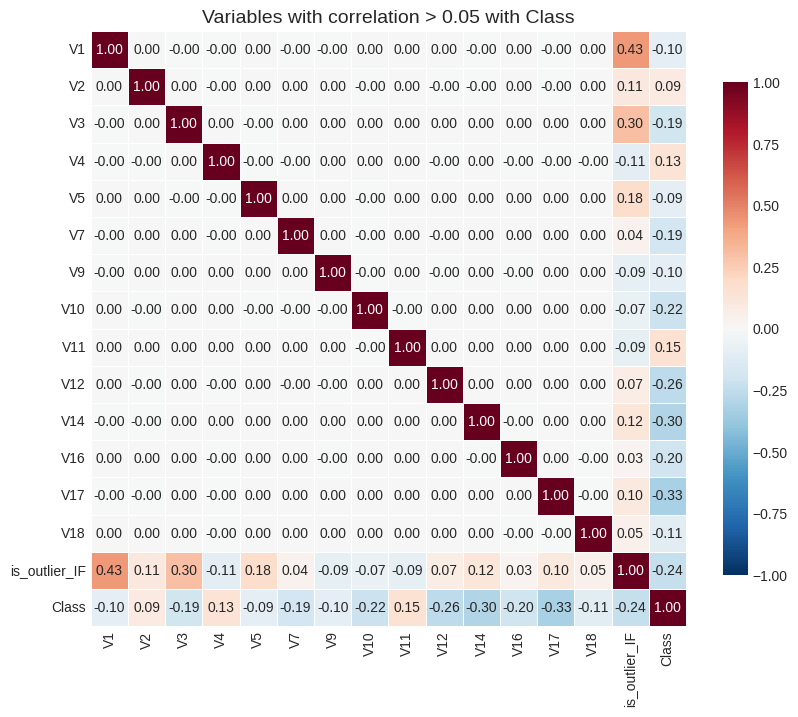

In [ ]:
print("\n📊 PART 1.8: CORRELATION WITH CLASS")
print("-" * 50)

target = 'Class'
umbral = 0.05  # Adjusted to 0.05 because correlations in this dataset are usually low (< 0.15)

df_analisis = Data.copy()
numerics = df_analisis.select_dtypes(include=['number']).columns.tolist()
cats_objs = df_analisis.select_dtypes(include=['object', 'category']).columns.tolist()
le = LabelEncoder()
for col in cats_objs:
    df_analisis[col] = df_analisis[col].astype(str)
    df_analisis[col] = le.fit_transform(df_analisis[col])

corrs_con_target = df_analisis.corr()[target]
features_importantes = corrs_con_target[abs(corrs_con_target) > umbral].drop(target)

print(f"--- Top Variables with correlation > {umbral} (Ranking) ---")
display(features_importantes.sort_values(key=abs, ascending=False))

cols_plot = features_importantes.index.tolist() + [target]
corr_matrix_plot = df_analisis[cols_plot].corr()

n_vars = len(cols_plot)
figsize_w = max(8, n_vars * 0.6)  # Dynamic size adjustment
figsize_h = max(6, n_vars * 0.5)

plt.figure(figsize=(figsize_w, figsize_h))
sns.heatmap(corr_matrix_plot,
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title(f'Variables with correlation > {umbral} with {target}', fontsize=14)
plt.show()

In [ ]:
corr=Data.corr(numeric_only=True)
corr
corr.style.background_gradient(cmap='coolwarm')

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,is_outlier_IF
Time,1.000000,0.117396,-0.010593,-0.419618,-0.105260,0.173072,-0.063016,0.084714,-0.036949,-0.008660,0.030617,-0.247689,0.124348,-0.065902,-0.098757,-0.183453,0.011903,-0.073297,0.090438,0.028975,-0.050866,0.044736,0.144059,0.051142,-0.016182,-0.233083,-0.041407,-0.005135,-0.009413,-0.010596,-0.012323,0.002806
V1,0.117396,1.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,-0.000000,0.000000,0.000000,-0.227709,-0.101347,0.432251
V2,-0.010593,0.000000,1.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000,-0.531409,0.091289,0.108601
V3,-0.419618,-0.000000,0.000000,1.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,-0.210880,-0.192961,0.300834
V4,-0.105260,-0.000000,-0.000000,0.000000,1.000000,-0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,-0.000000,0.098732,0.133447,-0.105211
V5,0.173072,0.000000,0.000000,-0.000000,-0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000,-0.386356,-0.094974,0.176434
V6,-0.063016,-0.000000,0.000000,0.000000,-0.000000,0.000000,1.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000,0.215981,-0.043643,-0.050314
V7,0.084714,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.397311,-0.187257,0.040281
V8,-0.036949,-0.000000,-0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,1.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.103079,0.019875,0.161665
V9,-0.008660,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.044246,-0.097733,-0.087068


## 10 Unidimensional Correlation/Association of Variables with the Target

In [ ]:
from scipy.stats import chi2_contingency, pointbiserialr

def analyze_advanced_association(df, target='Class'):
    """
    Calculates the association of variables with the target without external function dependencies.
    Includes recategorization of numerical identifiers.
    Note: The original `num_a_cat` and `num_a_bool` are commented out as they are not relevant
    for the 'creditcardfraud' dataset where V-features are continuous.
    """
    # 1. Definition of domains (Manual typing)
    # For 'creditcardfraud' dataset, most features are numerical and not categorical identifiers.
    # num_a_cat = [
    #     'Census_FirmwareManufacturerIdentifier', 'Census_FirmwareVersionIdentifier',
    #     'CityIdentifier', 'Census_ProcessorModelIdentifier', 'Wdft_RegionIdentifier',
    #     'Census_OEMModelIdentifier', 'AVProductStatesIdentifier', 'CountryIdentifier',
    #     'LocaleEnglishNameIdentifier'
    # ]
    # num_a_bool = ['Wdft_IsGamer', 'UacLuaenable']

    # 2. Dynamic type separation
    # Get original objects/categories + those we forced
    cats = df.select_dtypes(include=['object', 'category']).columns.tolist()
    # Assuming no such columns in this dataset, and the original lists are commented
    # cats = list(set(cats + num_a_cat))

    # Get numericals excluding those moved to cat/bool and the target
    nums = df.select_dtypes(include=['number']).columns.tolist()
    # nums = [c for c in nums if c not in cats and c not in num_a_bool and c != target]
    nums = [c for c in nums if c not in cats and c != target] # Adjusted for this dataset

    results = []

    # 3. Calculation of Cramér's V (Categorical)
    # This part will likely be skipped if 'cats' is empty for the 'creditcardfraud' dataset
    for col in cats:
        if col not in df.columns: continue
        obs = pd.crosstab(df[col], df[target])
        chi2 = chi2_contingency(obs)[0]
        n = obs.sum().sum()
        r, k = obs.shape

        phi2 = chi2 / n
        phi2_c = max(0, phi2 - ((k-1)*(r-1))/(n-1))
        r_c = r - ((r-1)**2)/(n-1)
        k_c = k - ((k-1)**2)/(n-1)

        v = np.sqrt(phi2_c / min((k_c-1), (r_c-1))) if min((k_c-1), (r_c-1)) > 0 else 0
        results.append({'feature': col, 'score': v, 'type': 'Cramér V'})

    # 4. Calculation of Point Biserial (Numerical)
    for col in nums:
        if col not in df.columns: continue
        series = df[col].fillna(df[col].median()) # Quick imputation for the test
        if series.nunique() > 1:
            r_pb, _ = pointbiserialr(df[target], series)
            results.append({'feature': col, 'score': abs(r_pb), 'type': 'Point Biserial'})

    # 5. Consolidation
    report = pd.DataFrame(results).sort_values('score', ascending=False)
    return report

def unidimensional_risk_visualization(df, target='Class', min_samples=100, top_n=15):
    # Initial filtering of irrelevant columns
    cols = [c for c in df.columns if c not in [target, 'Unnamed: 0', 'MachineIdentifier', 'Time', 'Amount', 'is_outlier_IF']] # Exclude Time, Amount, is_outlier_IF for this specific visualization if they are not to be grouped

    # Remove columns that are essentially continuous and not suitable for categorical grouping in this context
    # The 'V' features are PCA components and are already scaled/transformed. Grouping them by unique values might not be meaningful for this type of plot if there are many unique values.
    # This function is more suited for features with a reasonable number of discrete values or categories.
    # Given the creditcardfraud dataset, most 'V' features have a very large number of unique float values.
    # For this dataset, the focus should be on features that could be meaningfully grouped, if any.

    # For the 'creditcardfraud' dataset, the 'V' features are mostly continuous.
    # Let's adjust the `cols` selection to only include features that might have a limited number of unique values
    # or where grouping by value makes sense (e.g., if there were explicit categorical features, but there aren't here).
    # Given the nature of V1-V28 as PCA components, grouping them by unique values for this kind of plot might not be ideal
    # unless they are binned first, which is not part of this function.
    # Therefore, for 'creditcardfraud' dataset, this plot is most useful for features that are truly categorical or binned numerical.
    # Since the 'V' features are continuous, applying this directly will result in many individual points, which might be hard to interpret.
    # We'll run it, but note the limitation for continuous high-cardinality features.

    avg_global = df[target].mean()

    n_cols = 3
    # Ensure we only try to plot columns that actually exist in the filtered 'cols' list
    if not cols:
        print("No suitable columns found for unidimensional risk visualization after filtering.")
        return

    n_rows = (len(cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        if i >= len(axes): # Prevent index error if cols is larger than expected
            break

        # Use 'observed=True' to avoid FutureWarning for groupby on categorical columns, even if our current ones are numeric.
        # This assumes the values in 'col' are treated as discrete categories for grouping.
        stats = df.groupby(col, observed=True)[target].agg(['mean', 'count'])
        stats = stats[stats['count'] >= min_samples].nlargest(top_n, 'count').sort_values('mean')

        if not stats.empty:
            sns.scatterplot(
                ax=axes[i], x=stats['mean'], y=stats.index.astype(str),
                size=stats['count'], sizes=(40, 400), hue=stats['mean'],
                palette='RdYlGn_r', legend=False
            )
            axes[i].axvline(avg_global, color='black', linestyle='--', lw=1, alpha=0.5)
            axes[i].set(title=f"Risk: {col}", xlabel="Prob. Fraud", ylabel="")
            axes[i].tick_params(labelsize=8)
        else:
            axes[i].axis('off')

    # Turn off any remaining empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

print("Note: For the 'creditcardfraud' dataset with its predominantly continuous 'V' features,")
print("this visualization might show many individual points for each unique value, which can be dense.")
print("It is generally more impactful for genuinely categorical features or binned numerical features.")

Note: For the 'creditcardfraud' dataset with its predominantly continuous 'V' features,
this visualization might show many individual points for each unique value, which can be dense.
It is generally more impactful for genuinely categorical features or binned numerical features.



--- Advanced Association Report (Top 15) ---


,feature,score,type
17,V17,0.326481,Point Biserial
14,V14,0.302544,Point Biserial
12,V12,0.260593,Point Biserial
30,is_outlier_IF,0.241361,Point Biserial
10,V10,0.216883,Point Biserial
16,V16,0.196539,Point Biserial
3,V3,0.192961,Point Biserial
7,V7,0.187257,Point Biserial
11,V11,0.154876,Point Biserial
4,V4,0.133447,Point Biserial


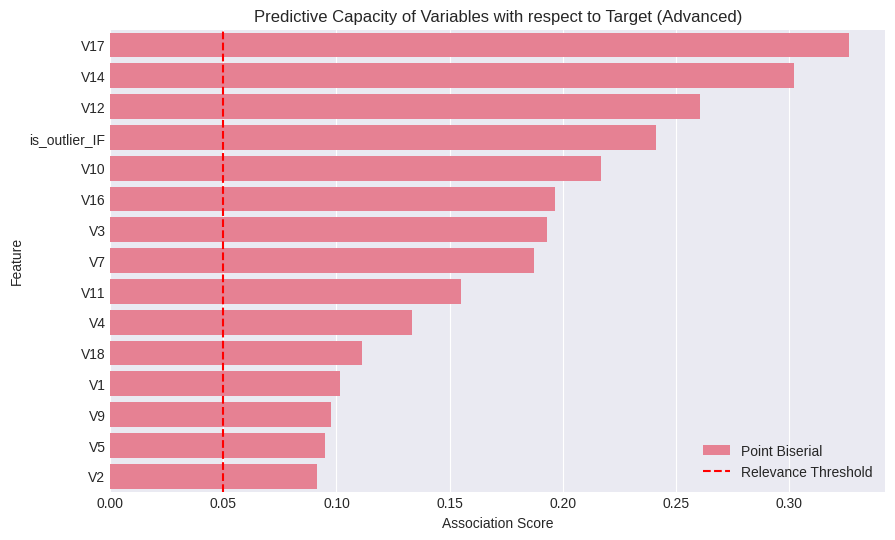


--- Unidimensional Risk Visualization ---


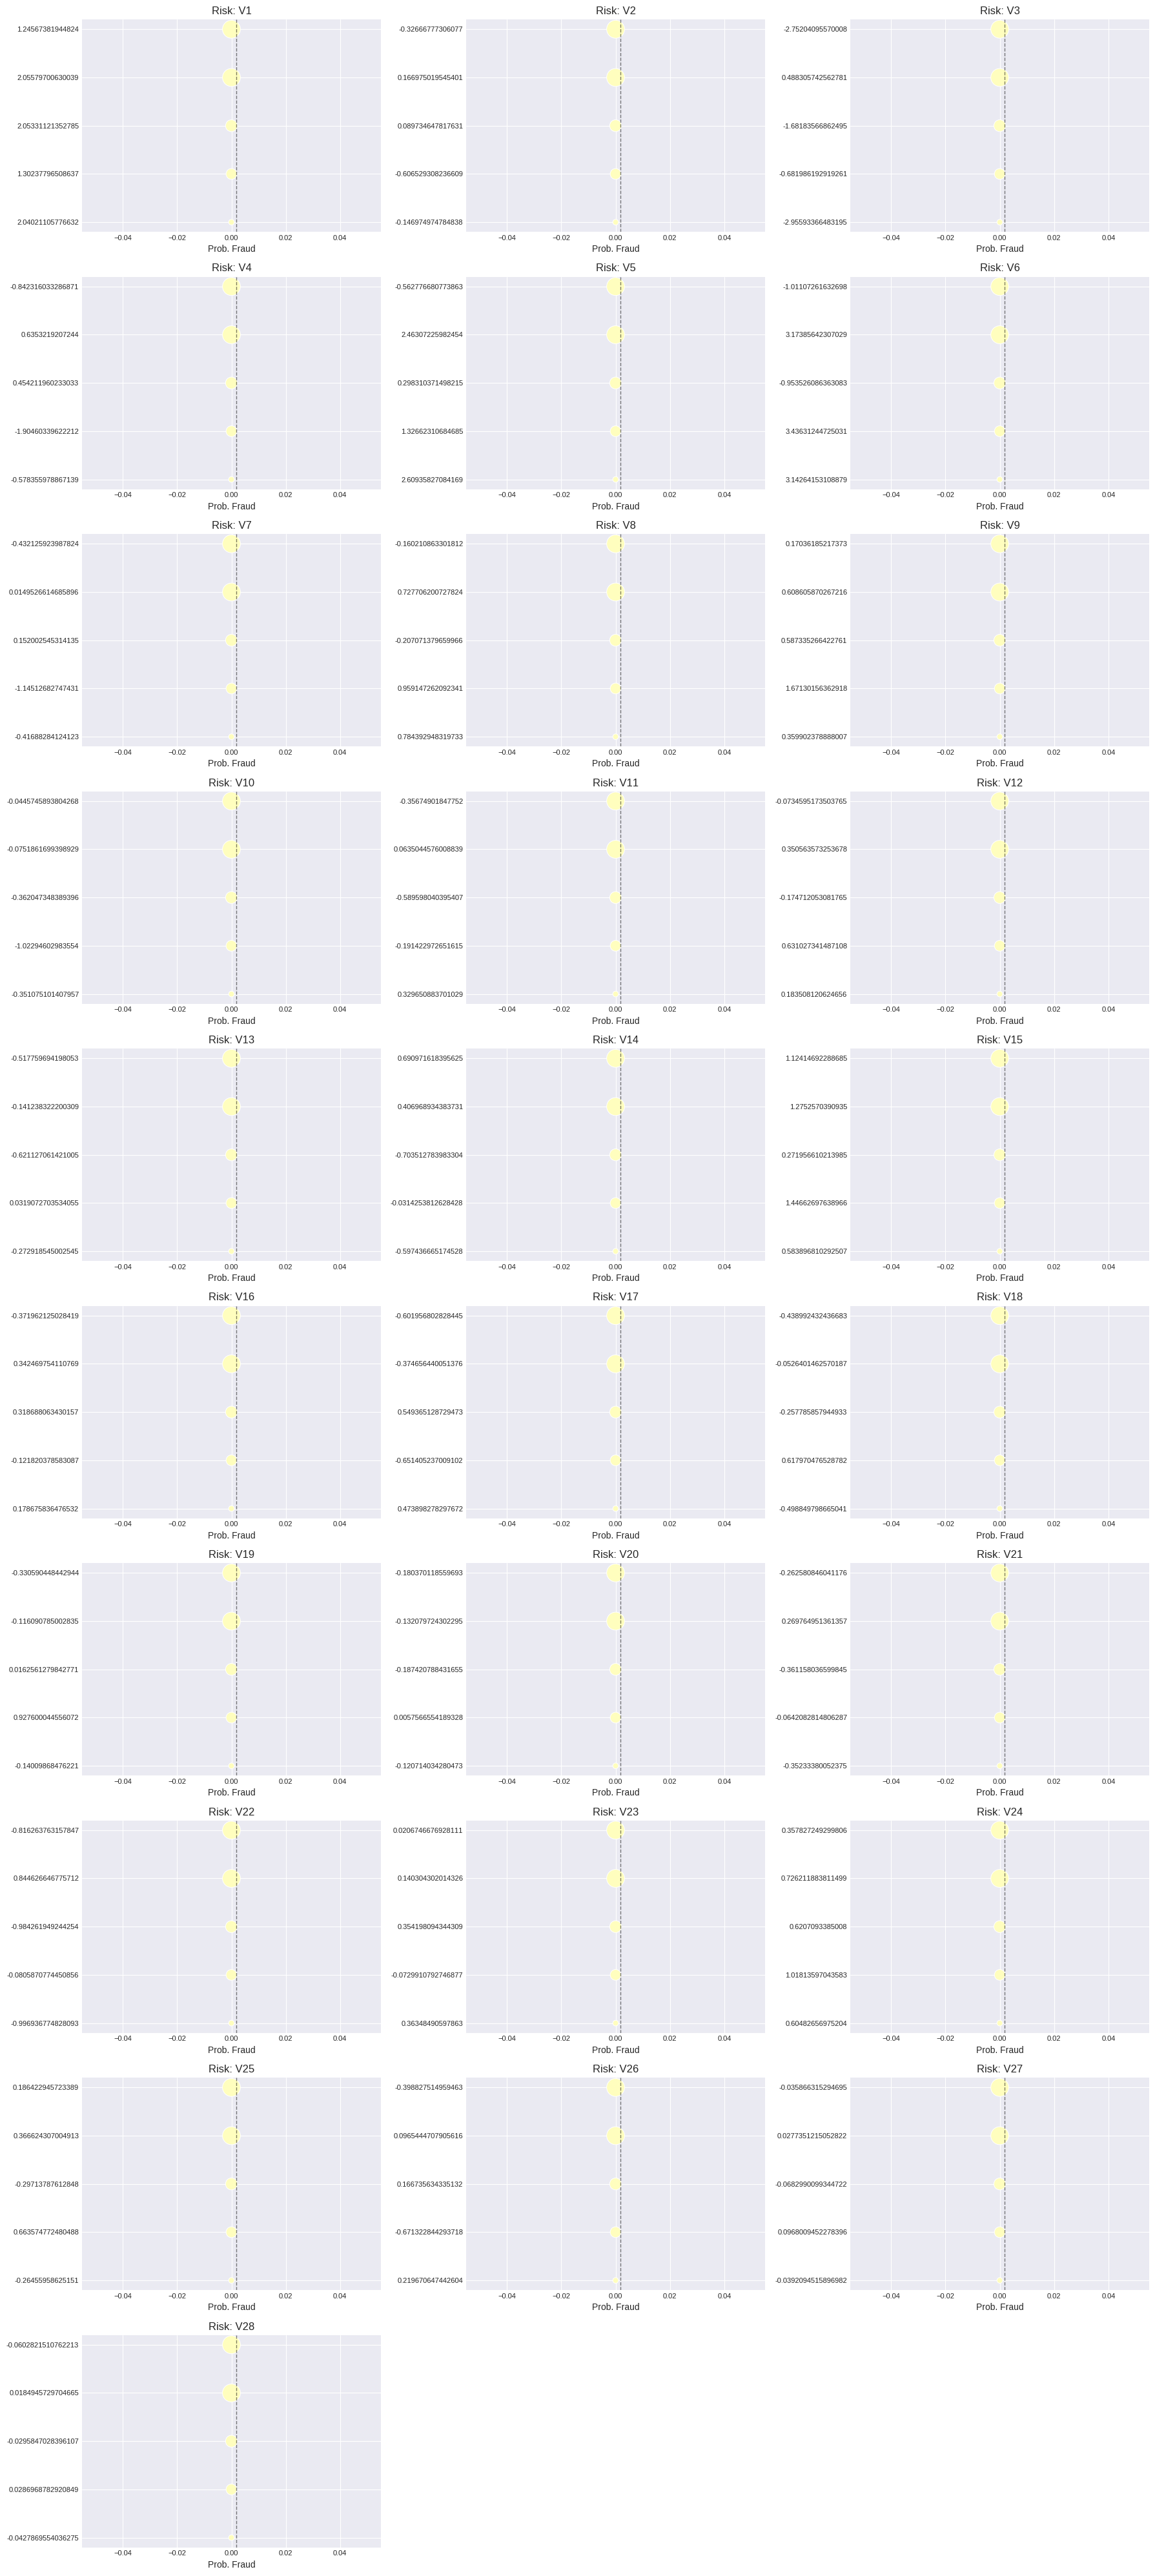

In [ ]:
# Execute the advanced association analysis
advanced_report_final = analyze_advanced_association(Data, target='Class')
print("\n--- Advanced Association Report (Top 15) ---")
display(advanced_report_final.head(15))

# Plot the results of the advanced association analysis
plt.figure(figsize=(10, 6))
sns.barplot(data=advanced_report_final.head(15), x='score', y='feature', hue='type')
plt.axvline(0.05, color='red', linestyle='--', label='Relevance Threshold')
plt.title('Predictive Capacity of Variables with respect to Target (Advanced)')
plt.xlabel('Association Score')
plt.ylabel('Feature')
plt.legend()
plt.show()

# Execute the unidimensional risk visualization (this might be very dense for V-features)
# Consider adjusting `min_samples` or `top_n` if plots are too dense or empty.
print("\n--- Unidimensional Risk Visualization ---")
unidimensional_risk_visualization(Data, target='Class', min_samples=50, top_n=10)


## 11. Graphical Visualization of Distributions

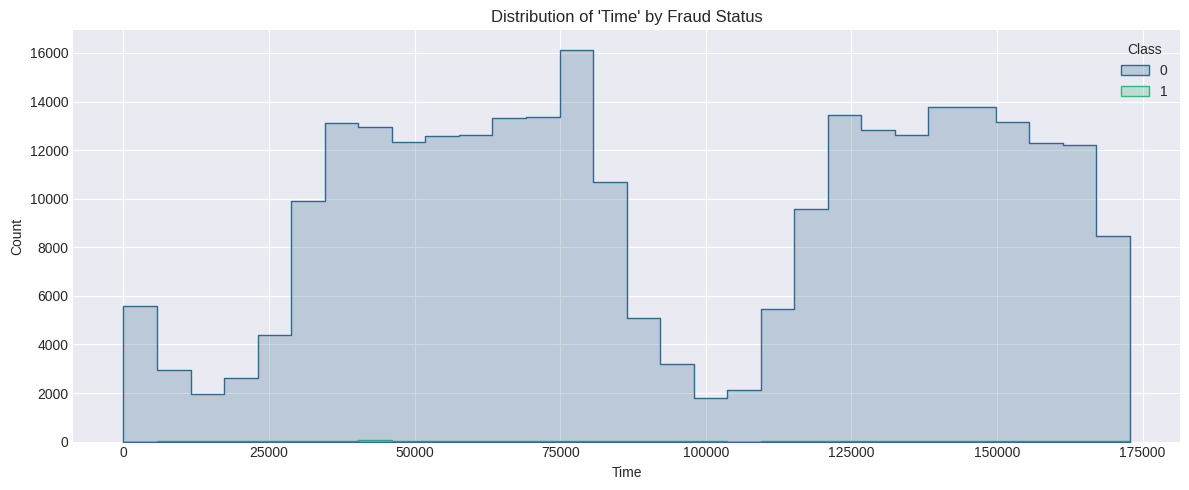

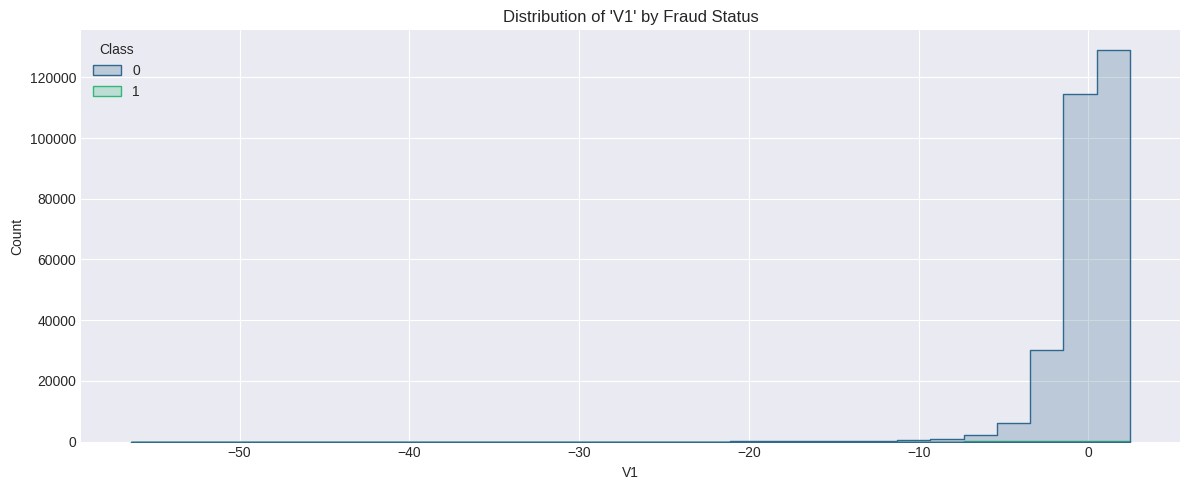

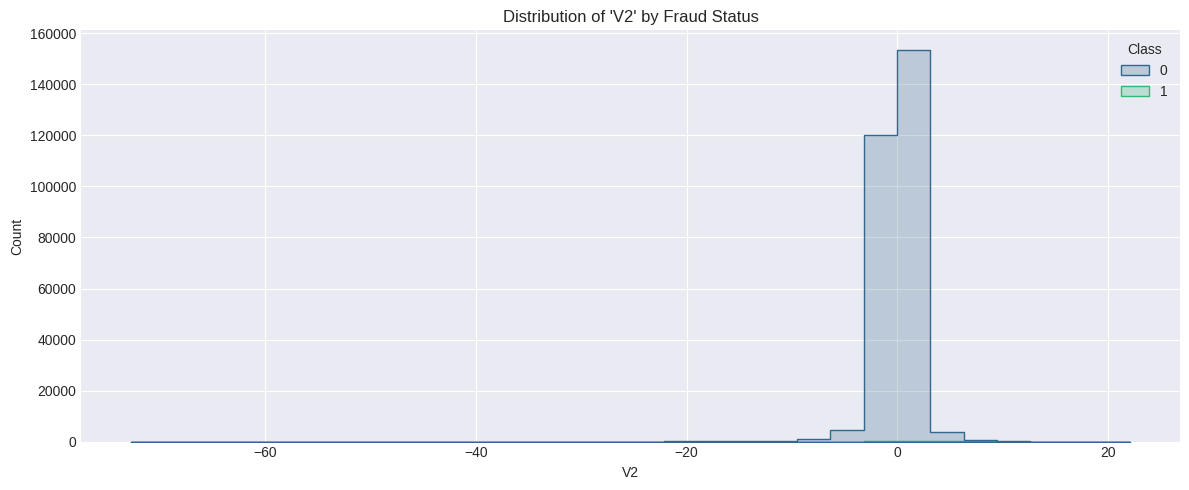

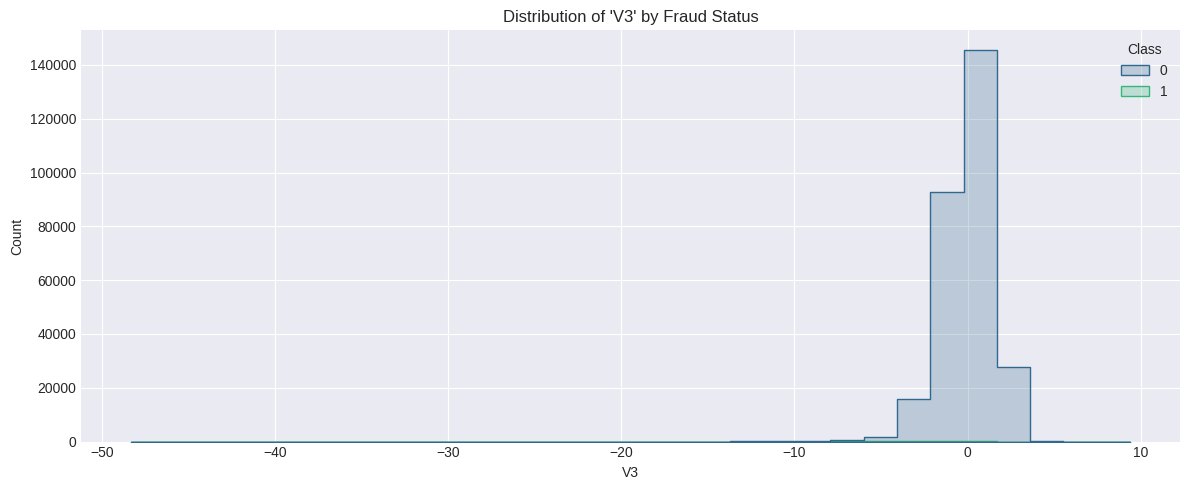

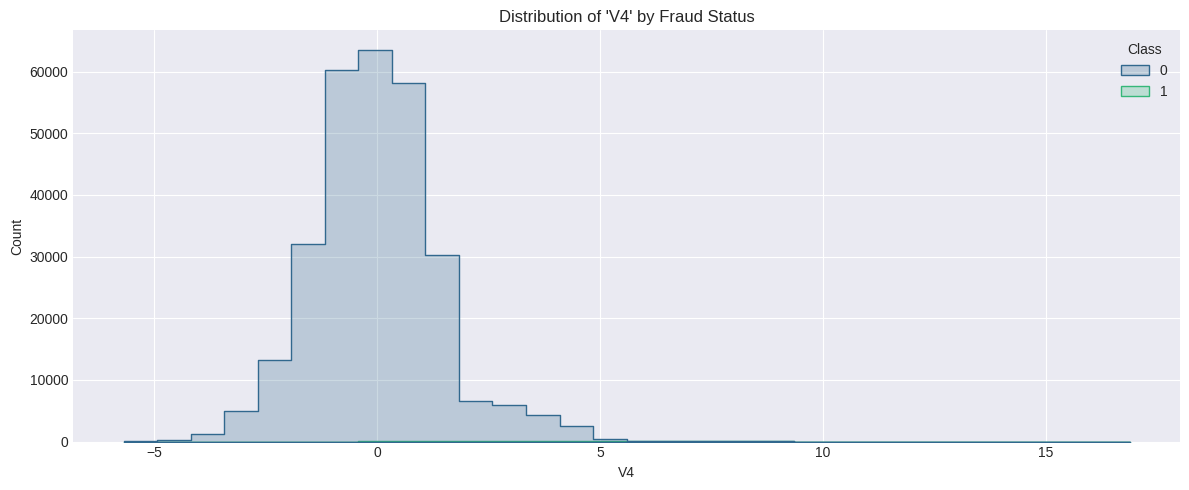

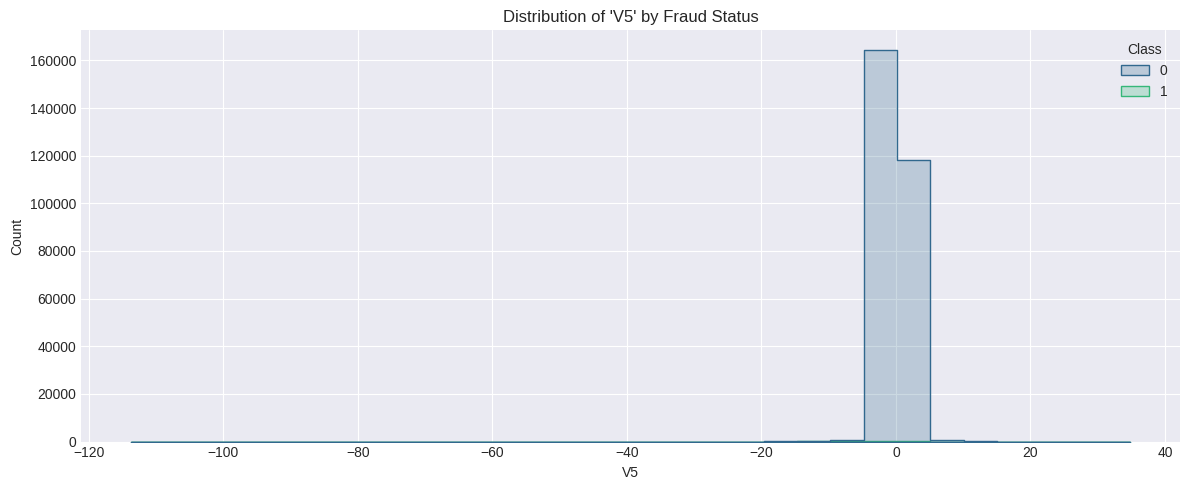

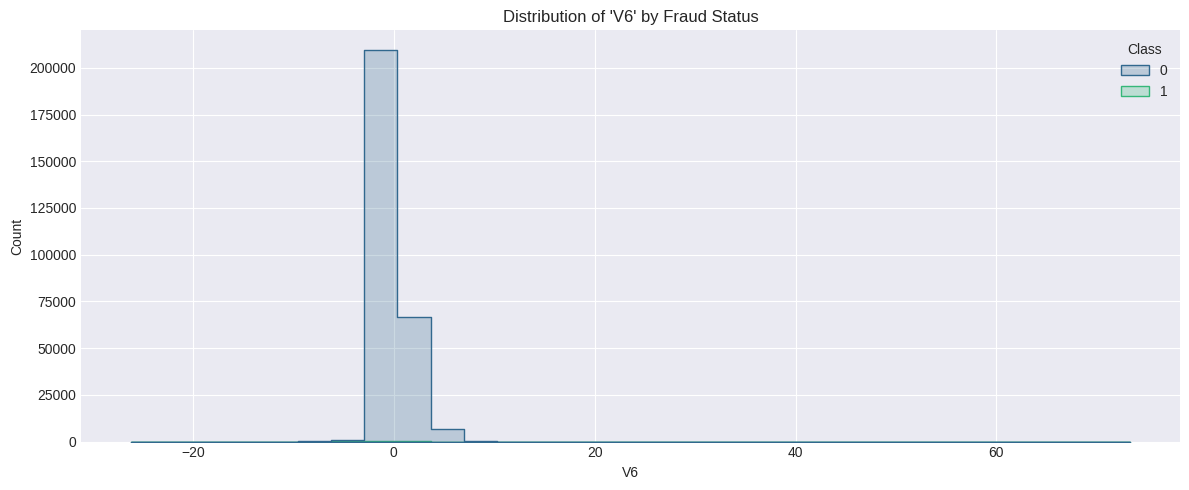

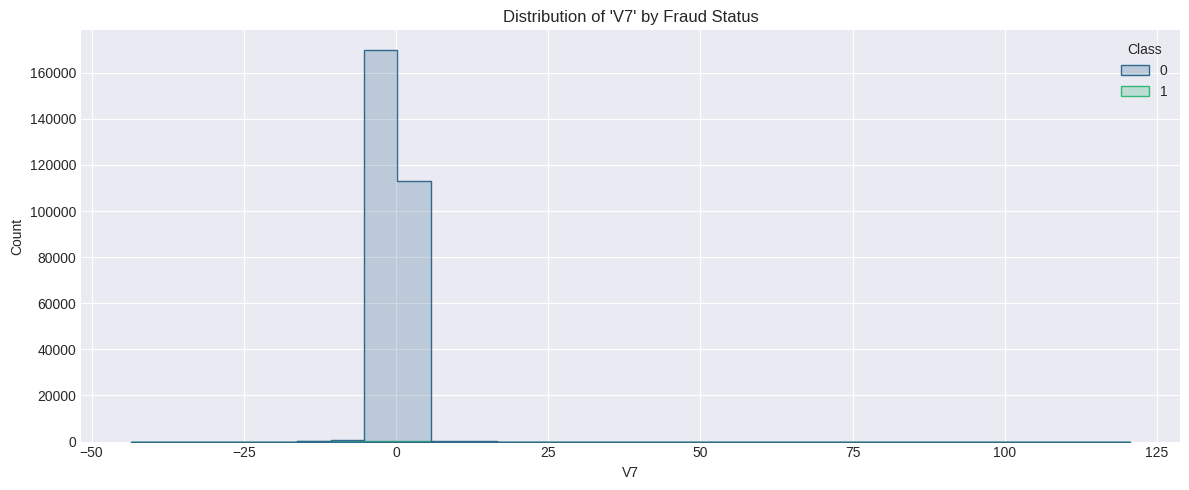

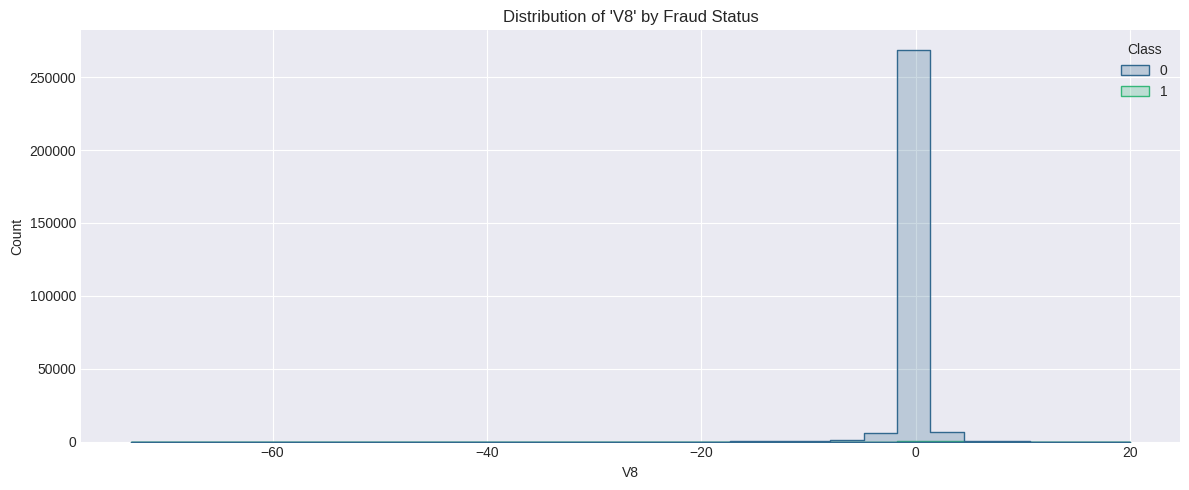

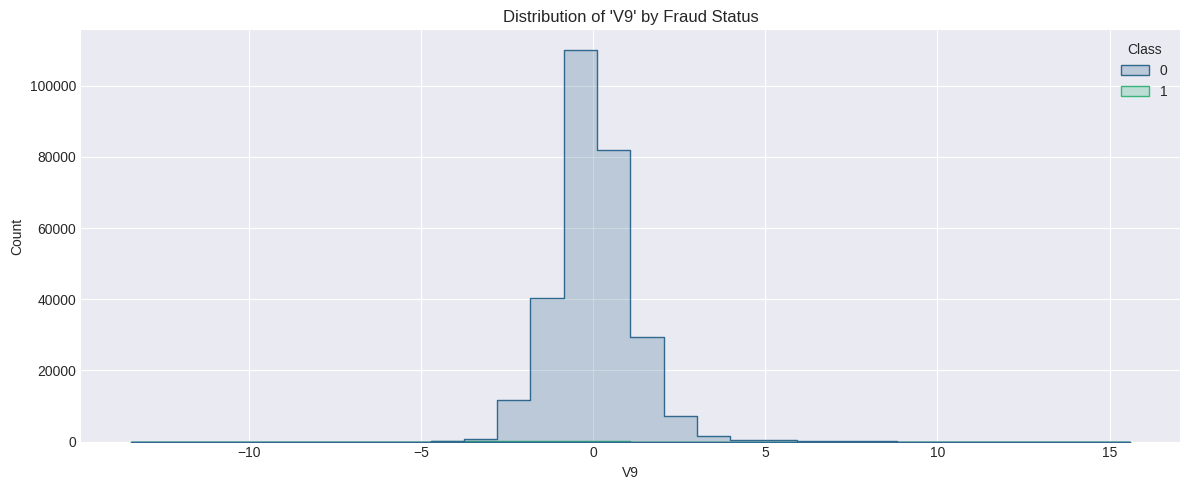

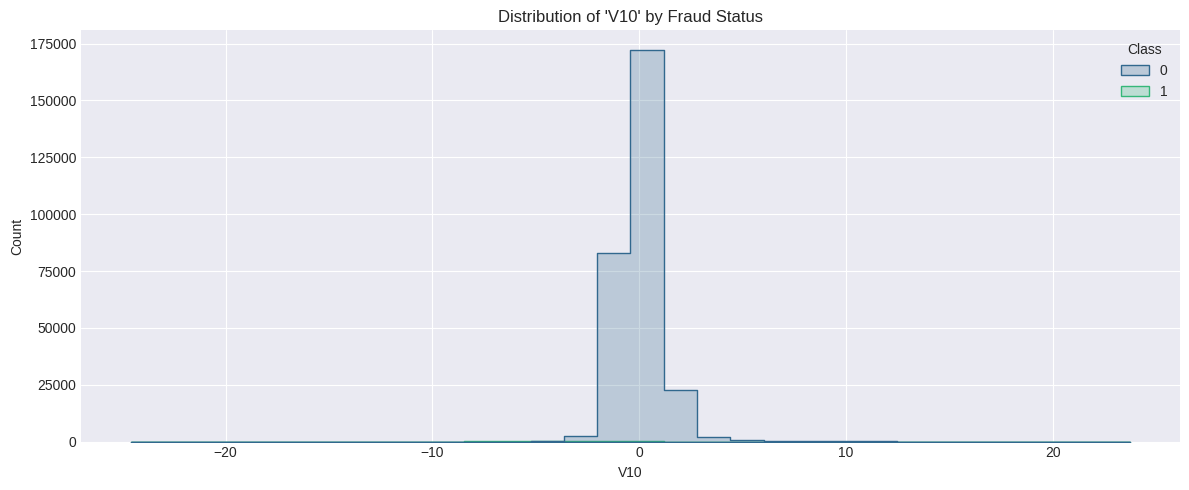

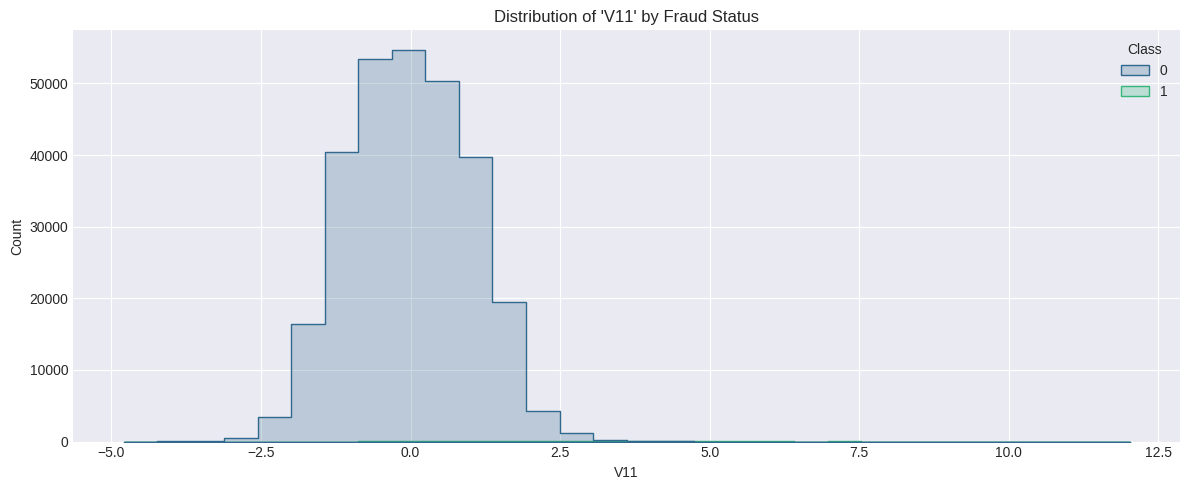

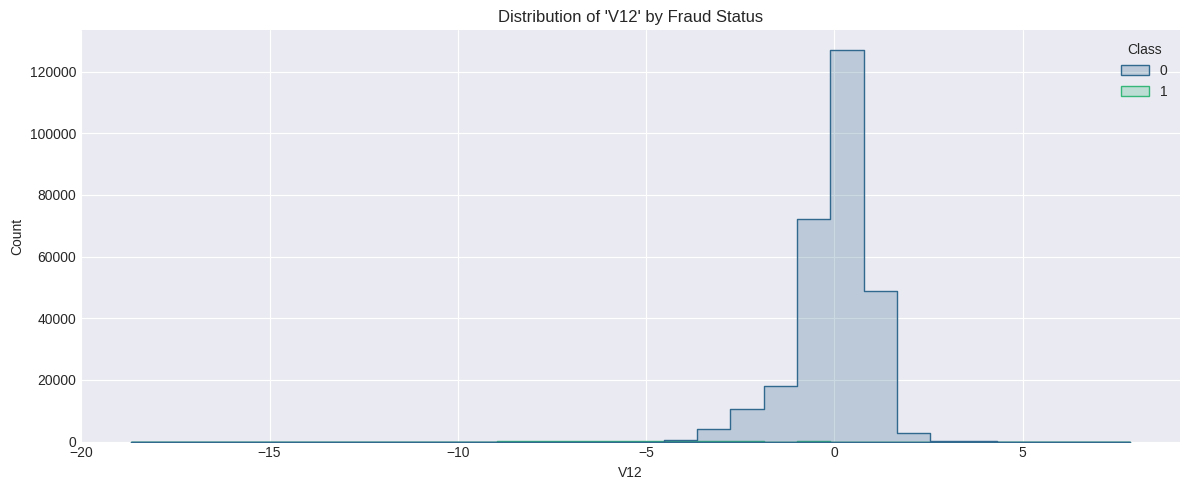

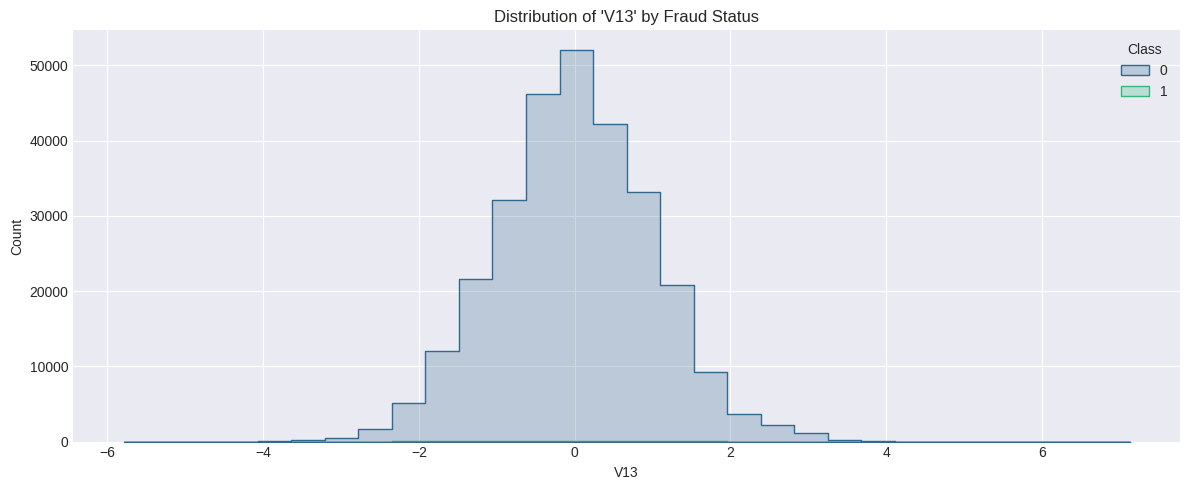

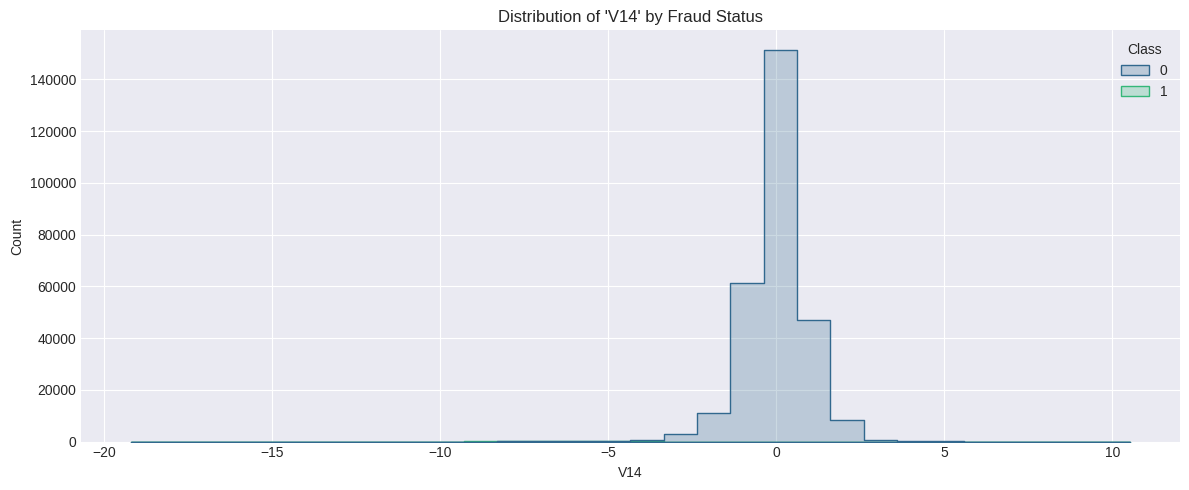

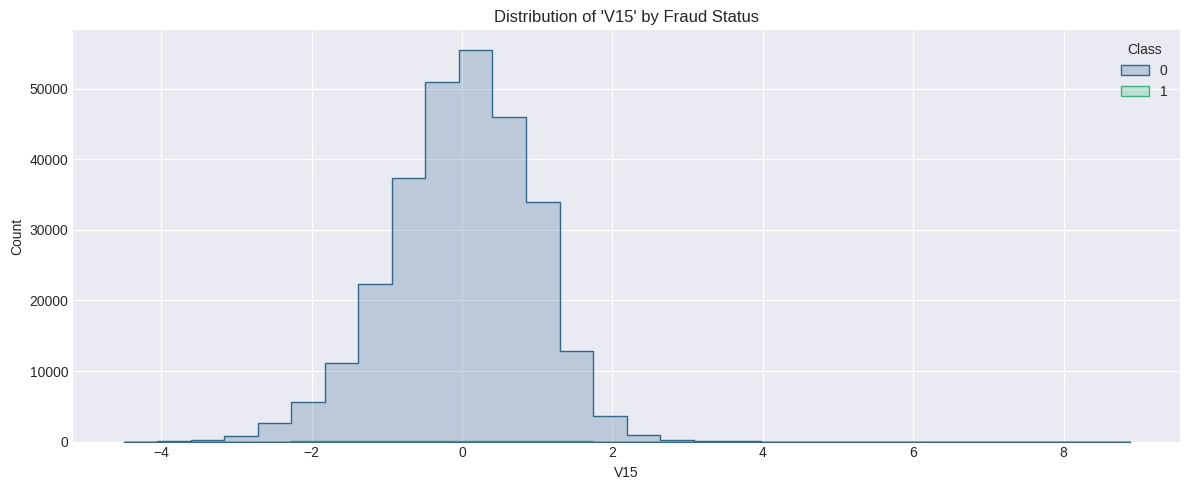

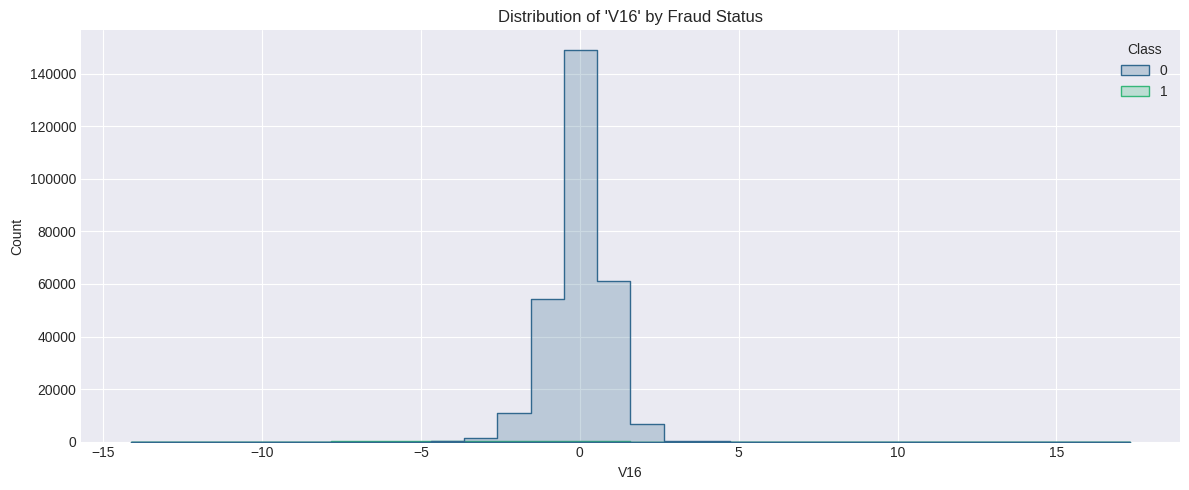

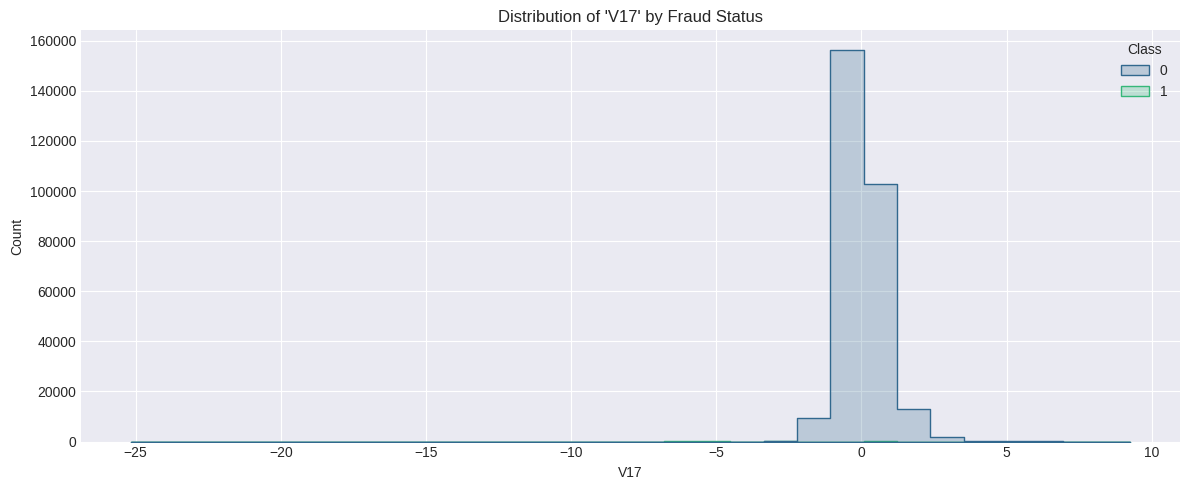

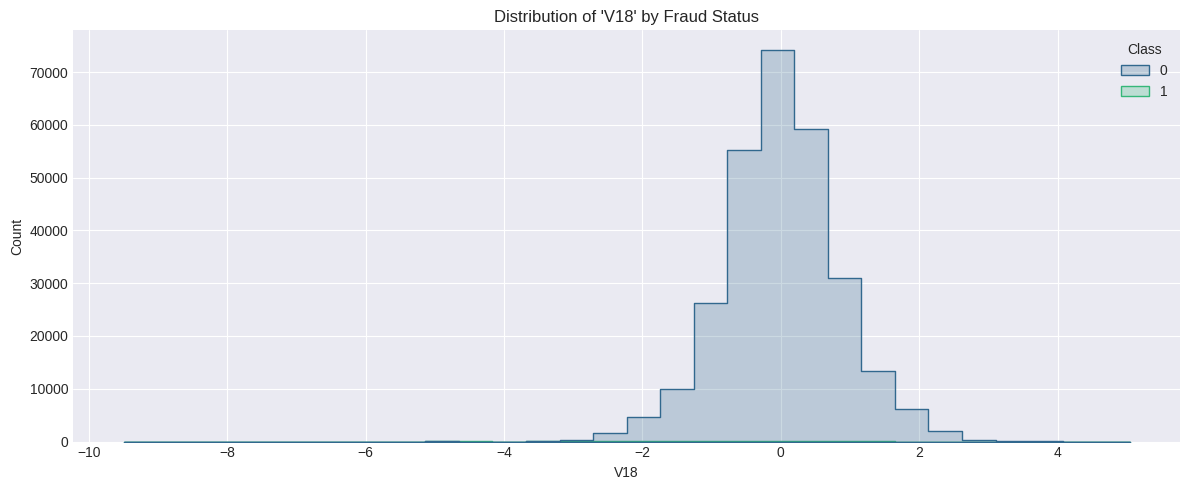

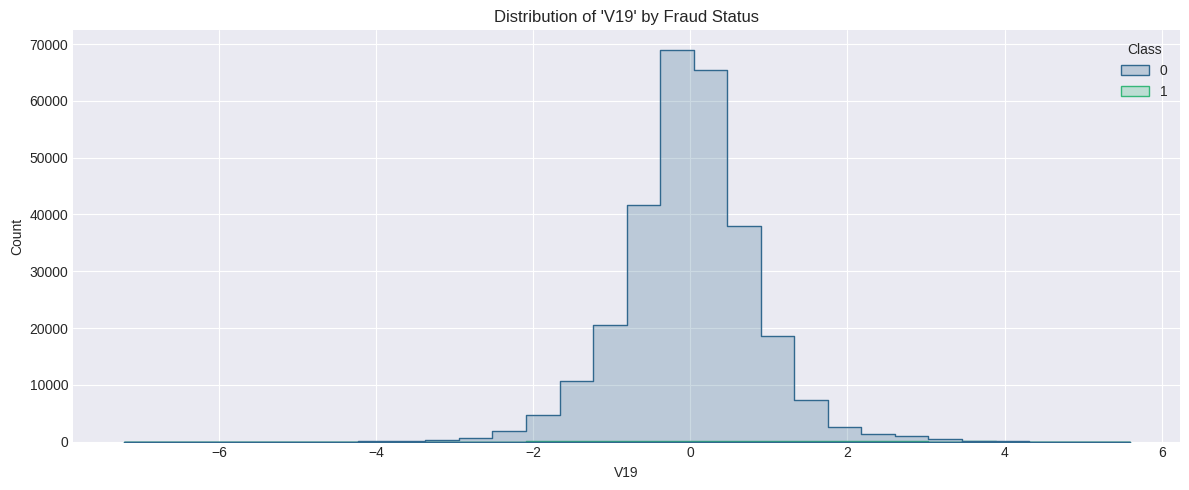

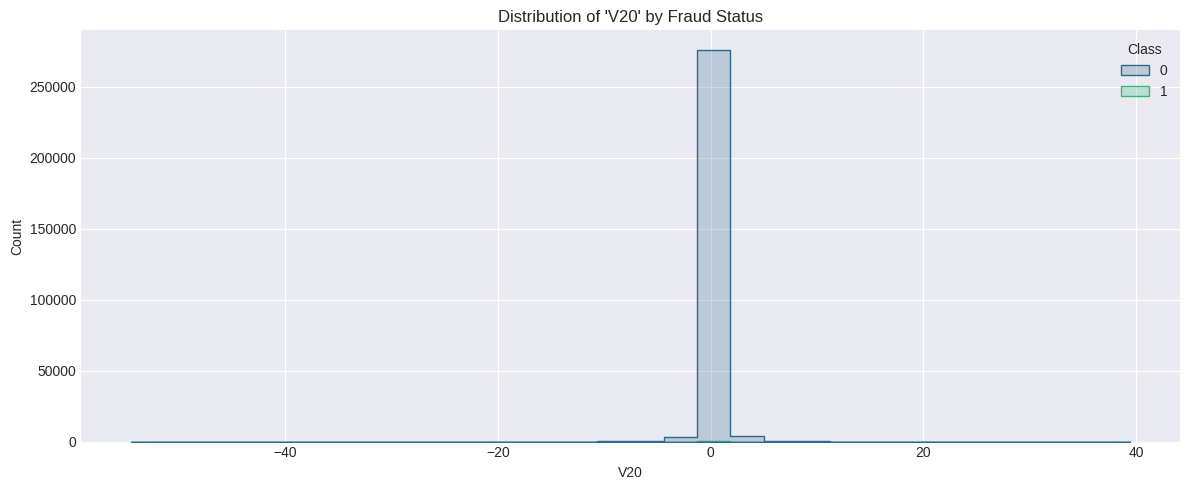

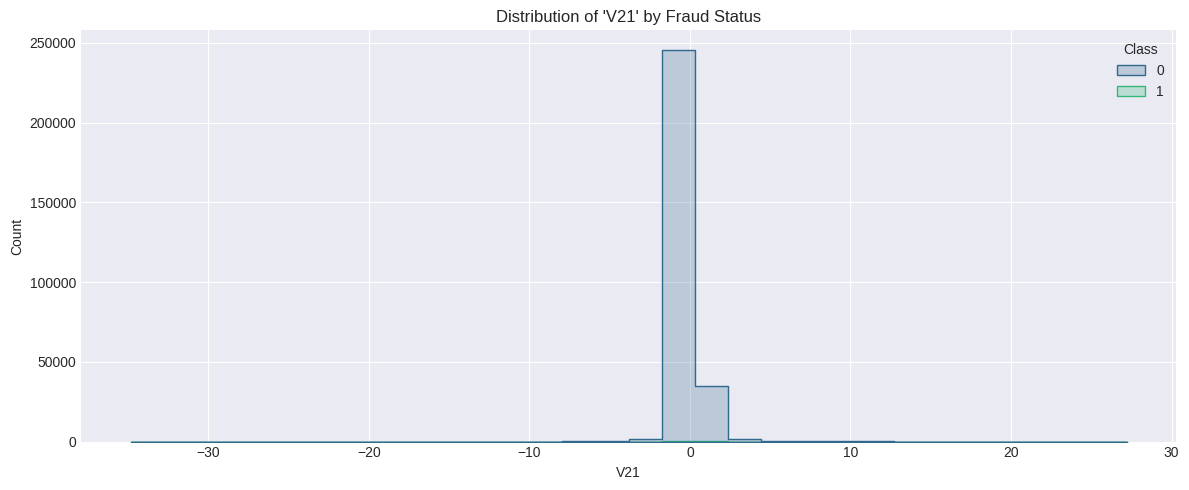

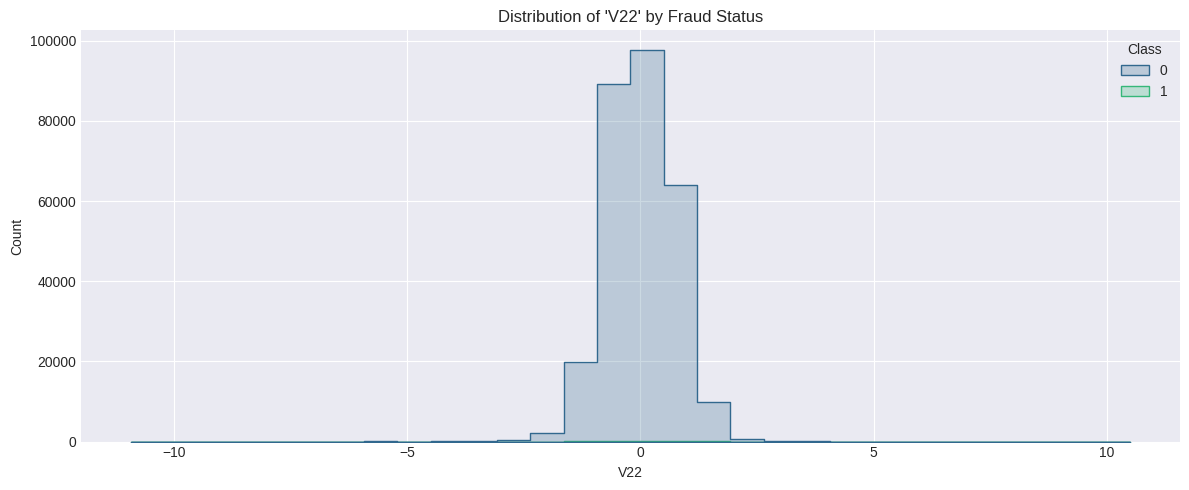

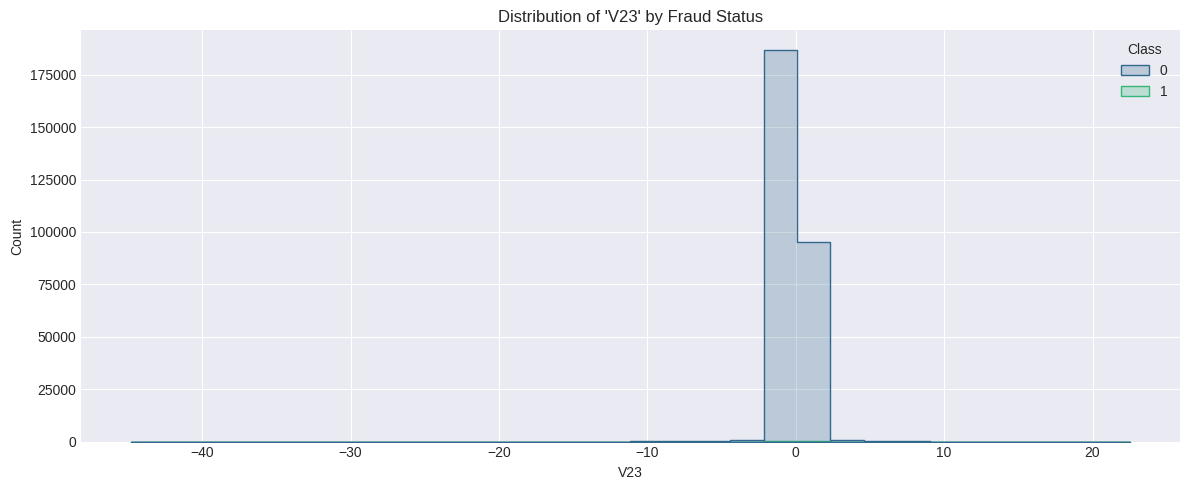

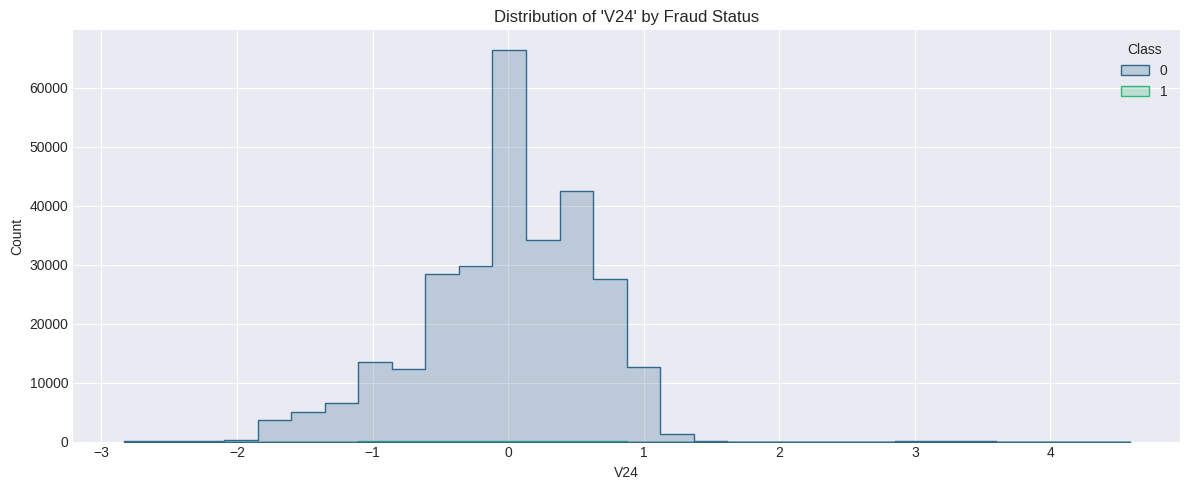

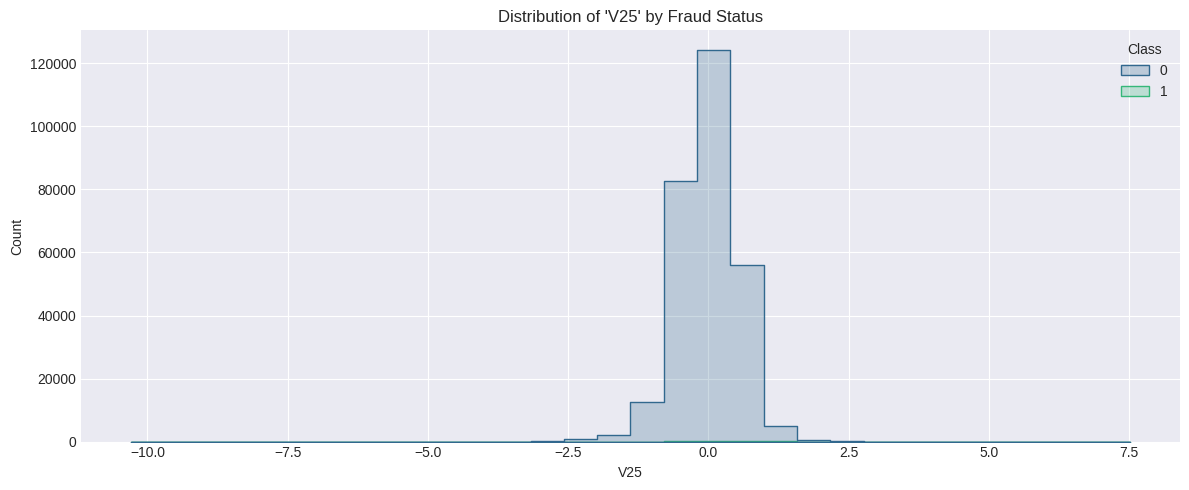

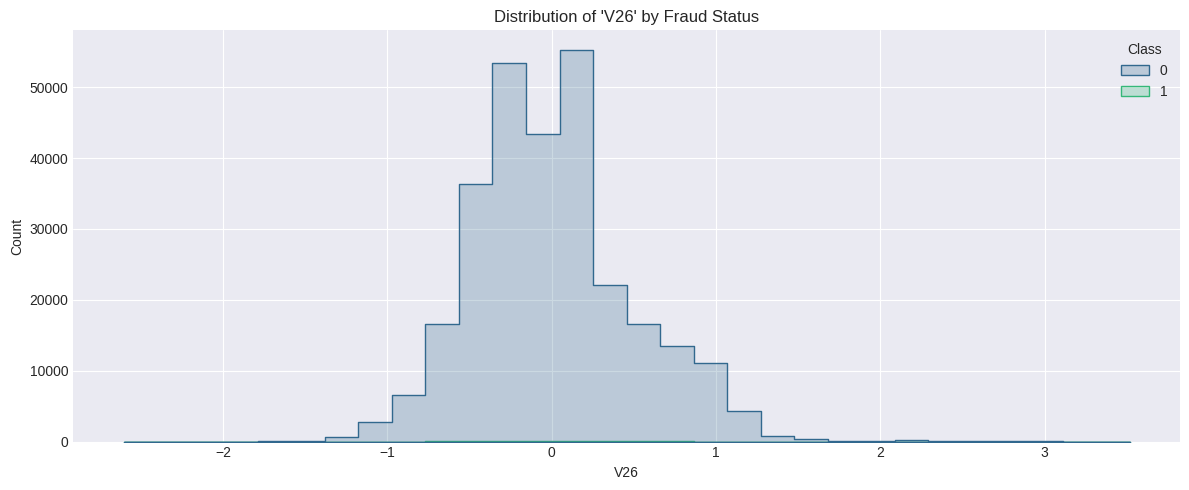

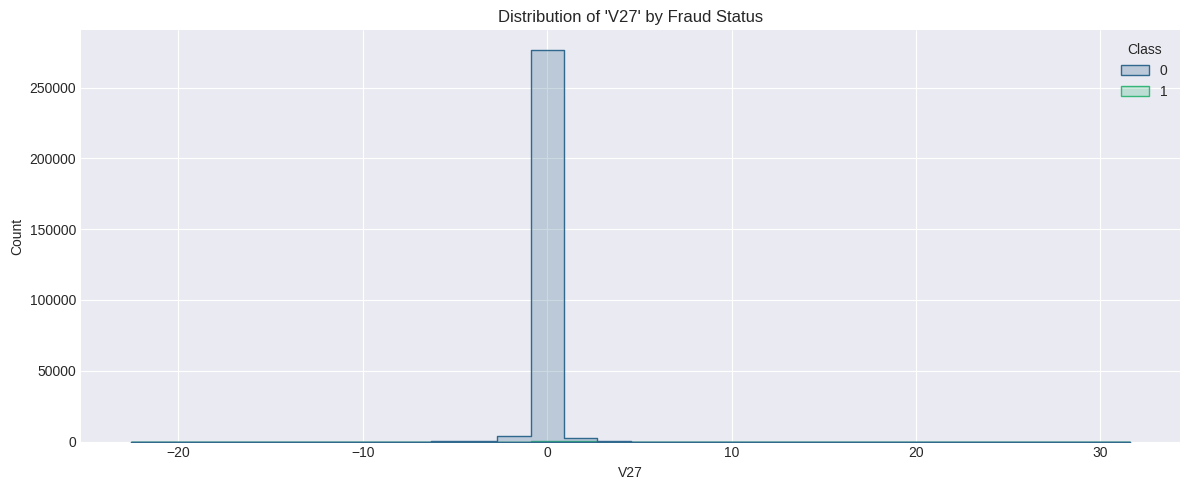

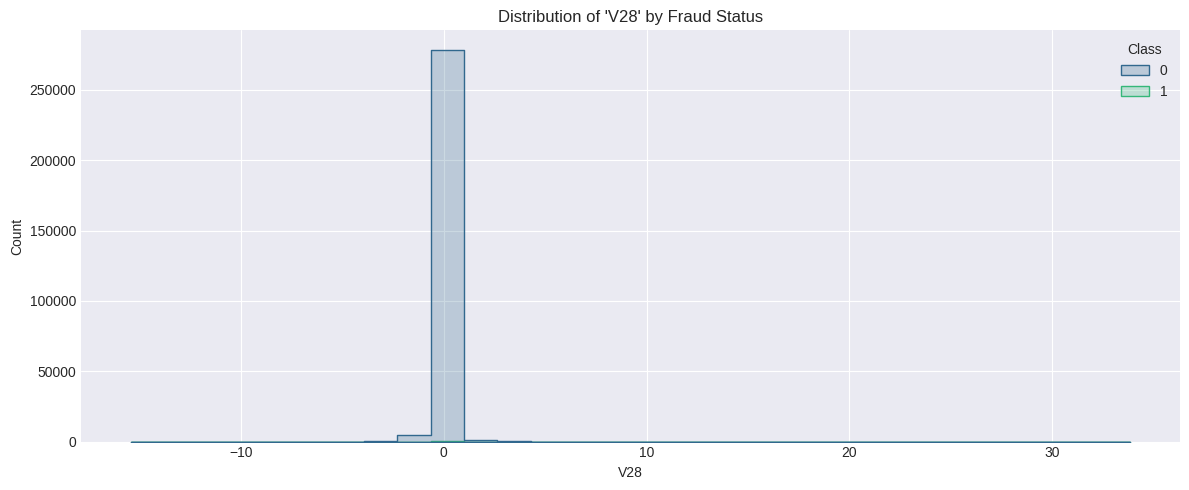

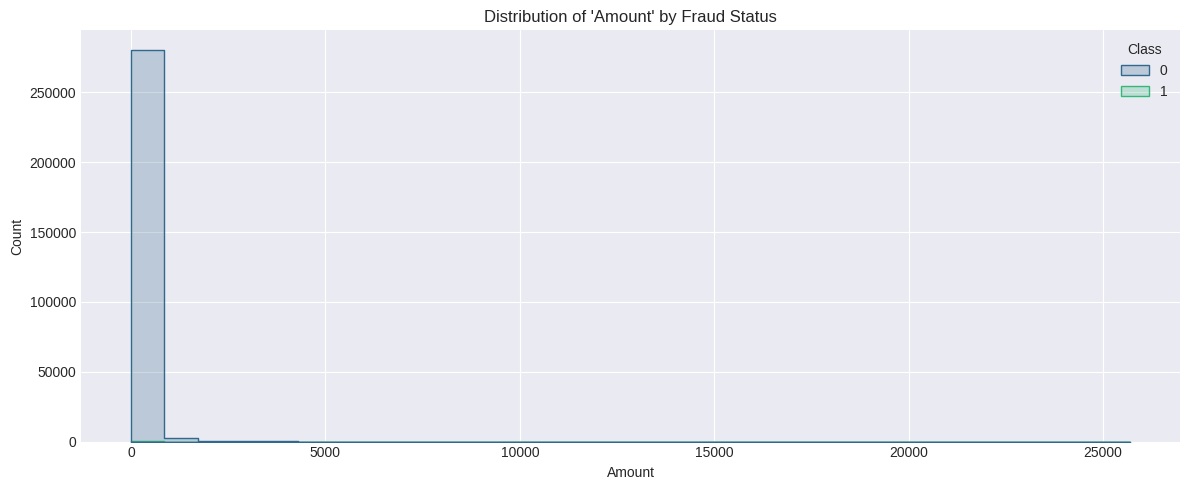

In [ ]:
# 2. Visualization loop
# We will iterate through all columns in our Data DataFrame
for col in Data.columns:
    # We skip the target variable and the Isolation Forest outlier indicator, as well as any other irrelevant identifiers
    # 'Unnamed: 0' and 'MachineIdentifier' are not in this dataset, but included for robustness if similar columns appear.
    if col in ['Class', 'is_outlier_IF']:
        continue

    # Get actual list of categorical and numerical column names for the current DataFrame
    # For the 'creditcardfraud' dataset, most V-features, Time, and Amount are numerical.
    # There are no explicit 'object' or 'category' dtypes after initial loading.
    categorical_cols = Data.select_dtypes(include=['object', 'category']).columns.tolist()
    numerical_cols = Data.select_dtypes(include=['int64', 'float64']).columns.tolist()

    plt.figure(figsize=(12, 5))

    if col in categorical_cols:
        # For categorical: Top 15 most frequent values to avoid saturating the X-axis
        # Given the creditcardfraud dataset, this block might not be extensively used as most features are numerical.
        top_values = Data[col].value_counts().nlargest(15).index
        df_plot = Data[Data[col].isin(top_values)]

        sns.countplot(data=df_plot, x=col, hue='Class', palette='viridis')
        plt.title(f"Top 15 categories in '{col}' vs Class")
        plt.xticks(rotation=45)

    elif col in numerical_cols:
        # For numerical: A histogram with KDE can be useful for distributions. We keep KDE=False as in the original code.
        sns.histplot(data=Data, x=col, hue='Class', kde=False, bins=30, element="step", palette='viridis')
        plt.title(f"Distribution of '{col}' by Fraud Status")

    plt.tight_layout()
    plt.show()

## 12. Distribution of Variables 2 by 2 (Scatter Plots)

   Found variables: 10 out of 10


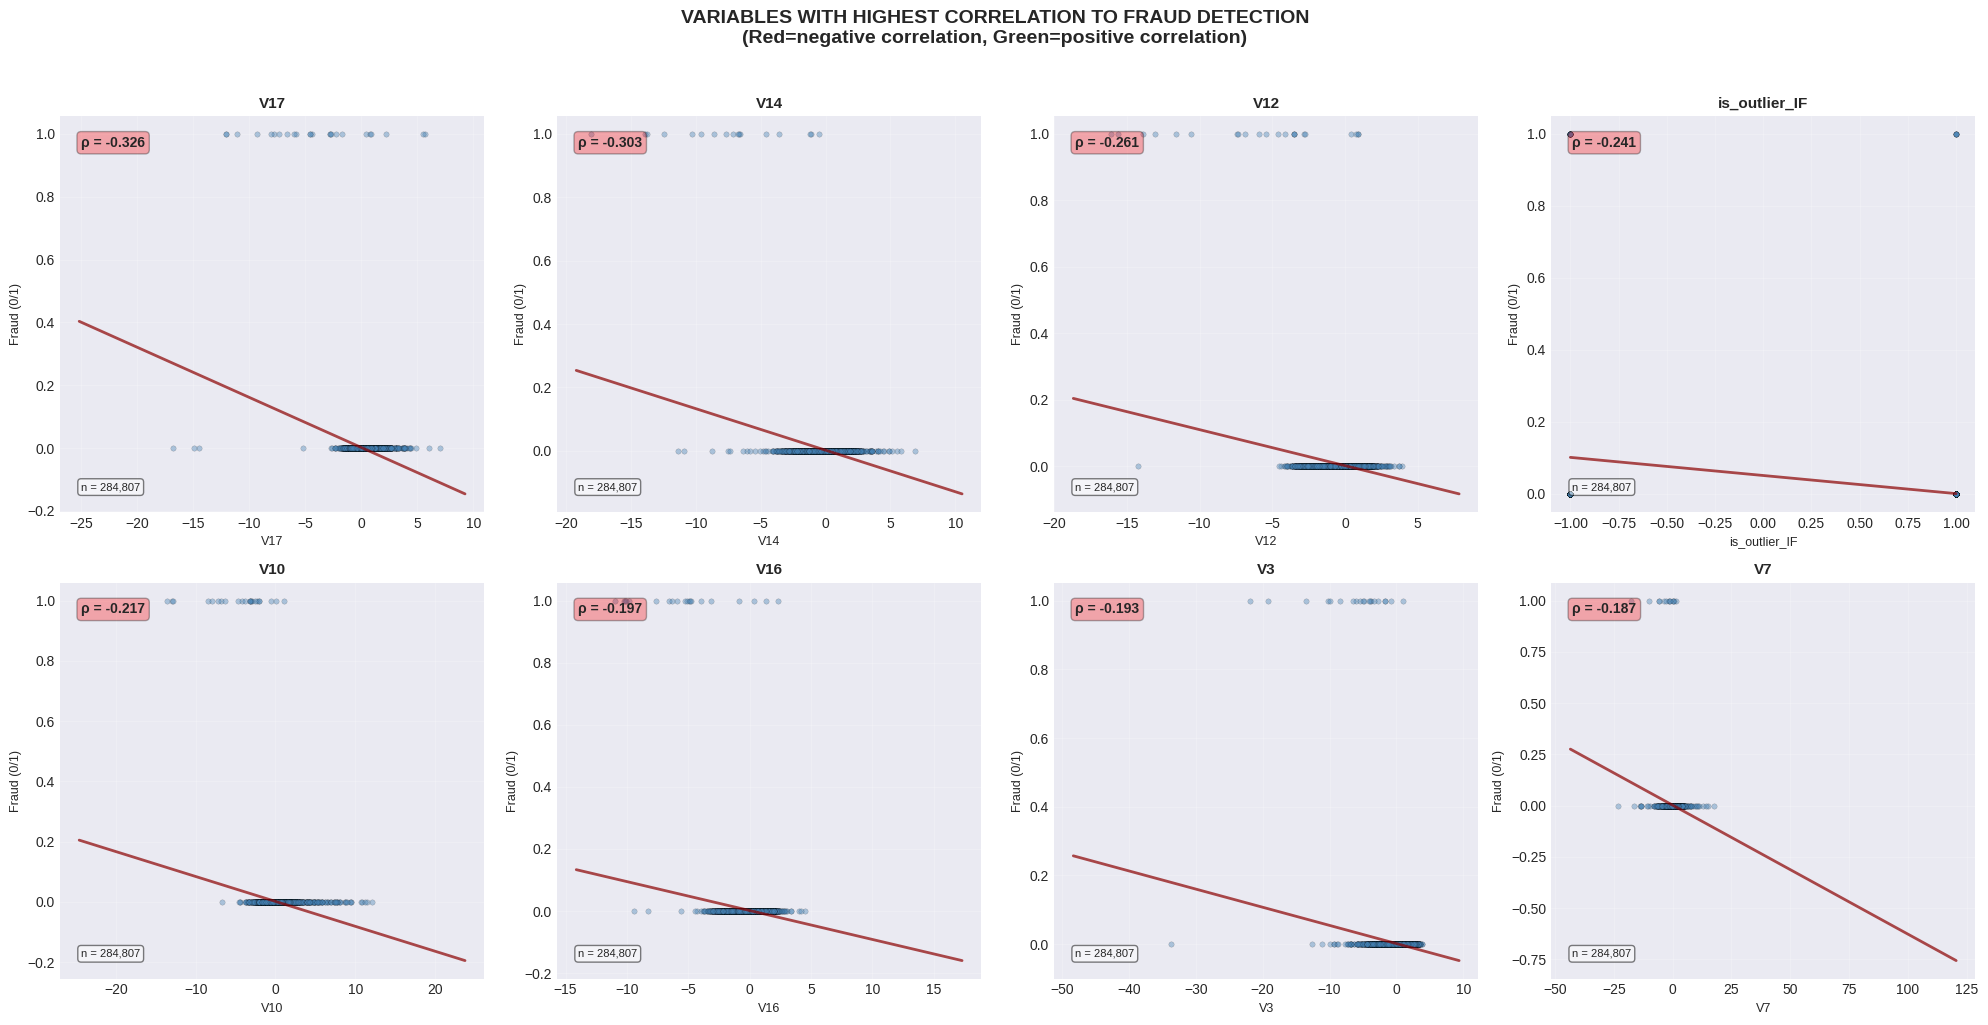


2. Correlation matrix between important variables:


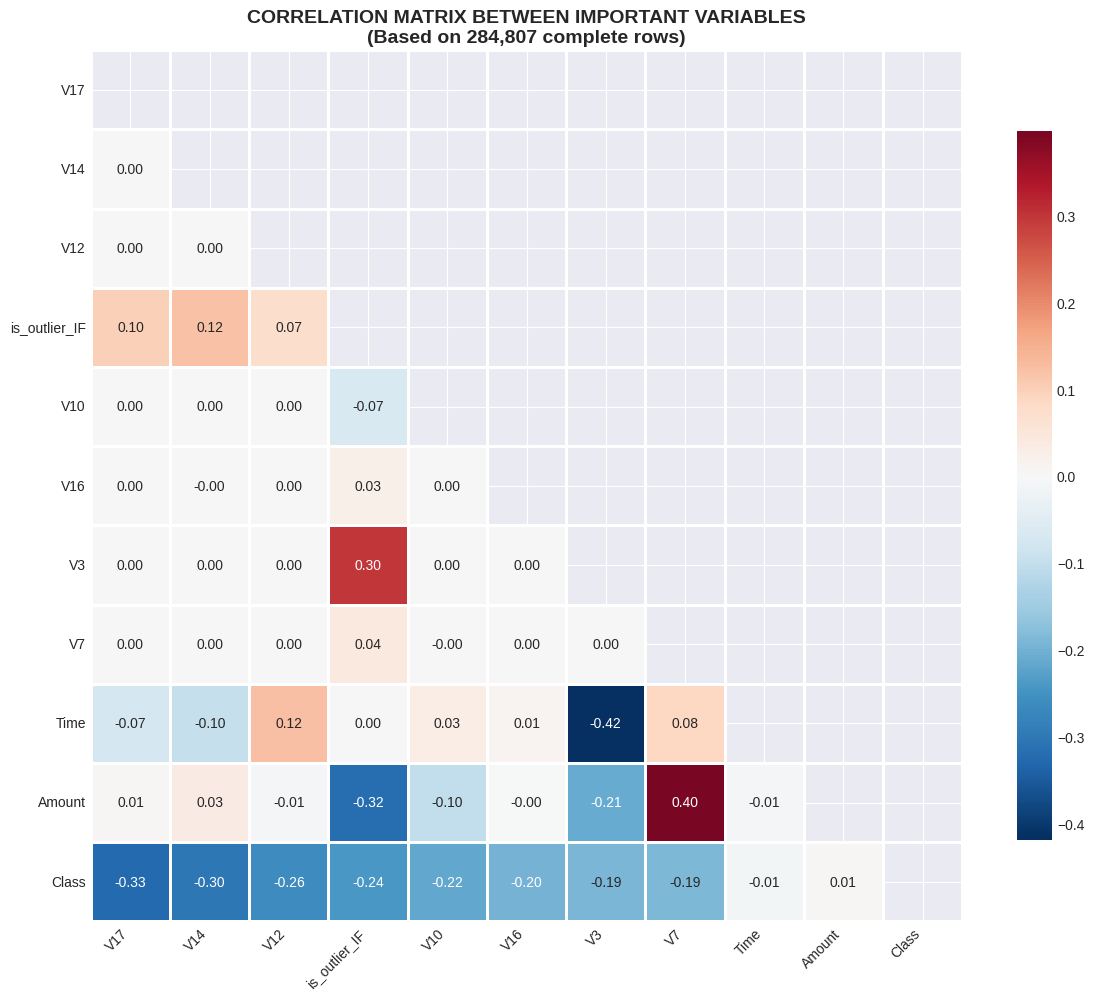


3. Summary of correlations with Class (n=284,807):
   V17                                 :   -0.3265
   V14                                 :   -0.3025
   V12                                 :   -0.2606
   is_outlier_IF                       :   -0.2414
   V10                                 :   -0.2169
   V16                                 :   -0.1965
   V3                                  :   -0.1930
   V7                                  :   -0.1873
   Time                                :   -0.0123
   Amount                              :   +0.0056


In [ ]:
# Variables with highest correlation (from our analysis)
# We'll use the top features identified in the advanced association report, plus Time and Amount
top_correlated_features = [
    'V17', 'V14', 'V12', 'is_outlier_IF', 'V10', 'V16', 'V3', 'V7',
    'Time', 'Amount'
]

# Filter only those that exist in our Data DataFrame
existing_variables = [v for v in top_correlated_features if v in Data.columns]
print(f"   Found variables: {len(existing_variables)} out of {len(top_correlated_features)}")

# Ensure we have enough variables to plot
if len(existing_variables) >= 4:
    # Create figure with 2x4 = 8 subplots (one per variable)
    # We'll plot the first 8 of the existing_variables against the target 'Class'
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for idx, variable in enumerate(existing_variables[:8]):  # Max 8 plots
        if idx < len(axes):
            ax = axes[idx]

            # For numerical variables (all our selected features are numerical)
            # Filter rows where both variables are not NaN (though our data has no NaNs)
            mask = Data[[variable, 'Class']].notna().all(axis=1)
            x_data = Data.loc[mask, variable]
            y_data = Data.loc[mask, 'Class']

            # Calculate correlation coefficient (Point-Biserial for numerical vs binary)
            corr_value = x_data.corr(y_data)
            color = 'red' if corr_value < 0 else 'green'
            sign = '-' if corr_value < 0 else '+'

            # Scatter plot for numerical variables
            # Plotting only a sample of points for performance and clarity due to large dataset size
            sample_size = min(len(x_data), 10000) # Plot max 10,000 points
            sample_indices = np.random.choice(x_data.index, size=sample_size, replace=False)
            ax.scatter(x_data.loc[sample_indices], y_data.loc[sample_indices],
                       alpha=0.4, s=15, color='steelblue', edgecolor='black', linewidth=0.2)

            # Add trend line (only if enough data)
            if len(x_data) > 1:
                try:
                    z = np.polyfit(x_data, y_data, 1)
                    p = np.poly1d(z)
                    sorted_idx = np.argsort(x_data)
                    ax.plot(x_data.iloc[sorted_idx],
                           p(x_data.iloc[sorted_idx]),
                           color='darkred', linewidth=2, alpha=0.7)
                except Exception:
                    pass  # If polyfit fails, continue without trend line

            # Label with correlation
            ax.text(0.05, 0.95, f'ρ = {sign}{abs(corr_value):.3f}',
                   transform=ax.transAxes, fontsize=10, fontweight='bold',
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor=color, alpha=0.3))

            # Add data count
            ax.text(0.05, 0.05, f'n = {len(x_data):,}',
                   transform=ax.transAxes, fontsize=8,
                   verticalalignment='bottom',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

            ax.set_title(f'{variable[:20]}', fontsize=11, fontweight='bold')
            ax.set_xlabel(variable[:15] + '...' if len(variable) > 15 else variable, fontsize=9)
            ax.set_ylabel('Fraud (0/1)', fontsize=9)
            ax.grid(True, alpha=0.2)

    # Adjust layout
    plt.suptitle('VARIABLES WITH HIGHEST CORRELATION TO FRAUD DETECTION\n' +
                '(Red=negative correlation, Green=positive correlation)',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # 2. Heatmap of correlations between these variables
    print("\n2. Correlation matrix between important variables:")

    # Filter only numerical variables (all our chosen are numerical)
    vars_numerical_for_corr = [v for v in existing_variables if Data[v].dtype in ['int64', 'float64']]
    vars_numerical_for_corr.append('Class')  # Add the target

    if len(vars_numerical_for_corr) > 2:
        # Filter complete rows (no NaN in any of the variables) - not strictly necessary as we have no NaNs
        complete_data = Data[vars_numerical_for_corr].dropna()
        if len(complete_data) > 0:
            corr_matrix = complete_data.corr()

            plt.figure(figsize=(12, 10))
            mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask for upper triangle
            sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r',
                                 center=0, fmt='.2f', linewidths=1,
                                 square=True, cbar_kws={"shrink": 0.8})

            plt.title('CORRELATION MATRIX BETWEEN IMPORTANT VARIABLES\n' +
                     f'(Based on {len(complete_data):,} complete rows)',
                     fontsize=14, fontweight='bold')
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()

            # Show strongest correlations with the target
            print(f"\n3. Summary of correlations with Class (n={len(complete_data):,}):")
            target_corrs = corr_matrix['Class'].drop('Class').sort_values(key=abs, ascending=False)
            for var, corr in target_corrs.head(10).items():
                sign = '  +' if corr > 0 else '  -'
                print(f"   {var:35} : {sign}{abs(corr):.4f}")
        else:
            print("   Not enough complete rows to calculate correlations")
else:
    print("Not enough relevant variables found for bivariate analysis.")

## 13. Training a Simple Random Forest Model for Credit Fraud Detection

In [ ]:
print("🌲 TRAINING SIMPLE RANDOM FOREST")
print("=" * 50)

# -----------------------------------------------------------------
# STEP 0: IMPORT ALL NECESSARY LIBRARIES
# -----------------------------------------------------------------
print("0️⃣ IMPORTING LIBRARIES...")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score

print("✅ Libraries imported successfully")

🌲 TRAINING SIMPLE RANDOM FOREST
0️⃣ IMPORTING LIBRARIES...
✅ Libraries imported successfully


In [ ]:
# -----------------------------------------------------------------
# STEP 1: SELECT VARIABLES
# -----------------------------------------------------------------
print("\n1️⃣ SELECTING IMPORTANT VARIABLES")

# Create a copy for modeling to avoid modifying the original 'Data' DataFrame directly
datos_modelo = Data.copy()
print(f"✓ Working with 'datos_modelo' (a copy of 'Data') with {datos_modelo.shape[0]} rows and {datos_modelo.shape[1]} columns")

# All V-features, Time, Amount, and is_outlier_IF are considered relevant for this dataset.
# The target variable is 'Class'.
# We will use all columns except 'Class' as features.

feature_columns = [col for col in datos_modelo.columns if col not in ['Class']]
target_column = 'Class'

print(f"Total features considered: {len(feature_columns)}")
print(f"Target variable: {target_column}")

# Verify that all selected features and the target exist in the DataFrame
existing_features = [col for col in feature_columns if col in datos_modelo.columns]
if len(existing_features) != len(feature_columns):
    missing_features = set(feature_columns) - set(existing_features)
    print(f"⚠️  WARNING: The following features are missing from the dataset: {missing_features}")
    feature_columns = existing_features # Use only existing features

if target_column not in datos_modelo.columns:
    print(f"❌ ERROR: The target variable '{target_column}' is not found in the dataset.")
    raise KeyError(f"Target variable '{target_column}' not found.")

print(f"✓ Using {len(feature_columns)} features for the model.")


1️⃣ SELECTING IMPORTANT VARIABLES
✓ Working with 'datos_modelo' (a copy of 'Data') with 284807 rows and 32 columns
Total features considered: 31
Target variable: Class
✓ Using 31 features for the model.


In [ ]:
# -----------------------------------------------------------------
# STEP 2: PREPARE DATA FOR MODEL
# -----------------------------------------------------------------
print("\n2️⃣ PREPARING DATA FOR THE MODEL")

# Separate X (features) and y (target)
X = datos_modelo[feature_columns] # Use the cleaned feature_columns list
y = datos_modelo[target_column]

print(f"✓ X (features): {X.shape[1]} columns")
print(f"✓ y (target): {len(y)} values")

# View target distribution
print(f"\n📊 Distribution of target ('{target_column}'):")
fraud_count = (y == 1).sum()
non_fraud_count = (y == 0).sum()
total_count = len(y)

print(f"  0 (No Fraud): {non_fraud_count:,} transactions ({non_fraud_count/total_count*100:.2f}%)")
print(f"  1 (Fraud): {fraud_count:,} transactions ({fraud_count/total_count*100:.2f}%)")

# Check for imbalance
if abs(fraud_count/total_count - 0.5) > 0.2:
    print(f"⚠️  ALERT! Dataset is highly imbalanced (fraud is {fraud_count/total_count*100:.2f}% of total).")

# Split into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y  # stratify to maintain proportion
)

print(f"\n✓ TRAINING Data: {X_train.shape[0]:,} transactions ({X_train.shape[0]/total_count*100:.1f}%)")
print(f"✓ TEST Data: {X_test.shape[0]:,} transactions ({X_test.shape[0]/total_count*100:.1f}%)")

# View distribution in each set
print(f"\nDistribution in training set:")
print(f"  Fraud: {(y_train == 1).sum():,} ({(y_train == 1).sum()/len(y_train)*100:.2f}%)")
print(f"Distribution in test set:")
print(f"  Fraud: {(y_test == 1).sum():,} ({(y_test == 1).sum()/len(y_test)*100:.2f}%)")


2️⃣ PREPARING DATA FOR THE MODEL
✓ X (features): 31 columns
✓ y (target): 284807 values

📊 Distribution of target ('Class'):
  0 (No Fraud): 284,315 transactions (99.83%)
  1 (Fraud): 492 transactions (0.17%)
⚠️  ALERT! Dataset is highly imbalanced (fraud is 0.17% of total).

✓ TRAINING Data: 199,364 transactions (70.0%)
✓ TEST Data: 85,443 transactions (30.0%)

Distribution in training set:
  Fraud: 344 (0.17%)
Distribution in test set:
  Fraud: 148 (0.17%)


In [ ]:
from sklearn.preprocessing import RobustScaler

print("\n3️⃣ APLICANDO ROBUSTSCALER A LOS DATOS DE ENTRENAMIENTO Y PRUEBA")

# Initialize RobustScaler
# It scales features using statistics that are robust to outliers.
# It removes the median and scales the data according to the quantile range (defaults to IQR).
scaler = RobustScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame with original column names and index
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✓ RobustScaler aplicado exitosamente.")
print(f"  X_train_scaled shape: {X_train_scaled.shape}")
print(f"  X_test_scaled shape: {X_test_scaled.shape}")



3️⃣ APLICANDO ROBUSTSCALER A LOS DATOS DE ENTRENAMIENTO Y PRUEBA
✓ RobustScaler aplicado exitosamente.
  X_train_scaled shape: (199364, 31)
  X_test_scaled shape: (85443, 31)


## 📈 STEP 3: Why ROC AUC and Precision-Recall AUC (PR-AUC) are Crucial for Imbalanced Data

When evaluating classification models, especially on highly imbalanced datasets like `creditcardfraud`, traditional metrics such as overall accuracy can be misleading. Here's why ROC AUC and PR-AUC offer a more insightful view of model performance:

### ROC AUC (Receiver Operating Characteristic - Area Under the Curve)

*   **What it measures**: ROC AUC plots the True Positive Rate (Sensitivity) against the False Positive Rate (1 - Specificity) across various classification thresholds. The AUC value represents the probability that the classifier will rank a randomly chosen positive instance higher than a randomly chosen negative instance.
*   **Why it's useful**: It provides an aggregate measure of performance across all possible classification thresholds. A high ROC AUC indicates that the model is generally good at distinguishing between positive and negative classes.
*   **Limitation with severe imbalance**: While ROC AUC is robust to class imbalance to some extent (as it focuses on ranks), it can still present an overly optimistic view when the negative class heavily outweighs the positive class. This is because a large number of True Negatives can significantly suppress the False Positive Rate, making even a poor minority class performance appear better than it is.

### Precision-Recall AUC (PR-AUC / Average Precision)

*   **What it measures**: PR-AUC plots Precision (the proportion of positive identifications that were actually correct) against Recall (the proportion of actual positives that were identified correctly) across various classification thresholds. The AUC value (also known as Average Precision) summarizes the precision-recall curve.
*   **Why it's highly recommended for imbalance**: For highly imbalanced datasets, PR-AUC is often a much more informative and realistic metric than ROC AUC.
    *   **Focus on the positive class**: Both precision and recall focus on the positive (minority) class. Precision is concerned with the purity of the positive predictions, and recall with the completeness of positive predictions.
    *   **Sensitivity to False Positives**: When the negative class is vast, even a small number of False Positives can lead to a drastic drop in precision. PR-AUC is highly sensitive to these changes, giving a more accurate reflection of a model's ability to identify the rare positive class without being overwhelmed by false alarms. If a model performs poorly on the minority class, its PR-AUC will be low, even if its ROC AUC is high.
*   **Interpretation**: A high PR-AUC indicates that the model is able to retrieve a high percentage of positive cases (high recall) while maintaining a high accuracy in those retrievals (high precision). For fraud detection, where identifying actual fraud (high recall) is critical, and minimizing false alarms (high precision) is also important, PR-AUC directly captures this trade-off.

### Conclusion

For our `creditcardfraud` dataset, where fraud instances are extremely rare, **PR-AUC is the primary metric to optimize and monitor**. While ROC AUC provides a general sense of discriminative power, PR-AUC gives a more honest and actionable assessment of the model's performance in the challenging task of detecting the minority class.

## 🚀 STEP 4: ADDRESSING CLASS IMBALANCE WITH SMOTE

While `class_weight='balanced'` helps by assigning higher penalties to misclassified minority samples, explicit resampling techniques can often lead to more significant improvements in handling class imbalance. Here, we will use **SMOTE (Synthetic Minority Over-sampling Technique)** to oversample the minority class in the *training data only*.

### How SMOTE Works:
SMOTE works by creating synthetic samples along the line segments joining any of the `k` minority class nearest neighbors. This helps to create a more balanced dataset for the classifier to learn from, without simply duplicating existing minority samples, which can lead to overfitting.

### Important Considerations:
*   **Apply only to training data**: As highlighted in best practices, SMOTE *must only* be applied to the training set (`X_train`, `y_train`). Applying it to the test set would lead to data leakage and overly optimistic evaluation metrics.
*   **No `class_weight` needed (usually)**: When using SMOTE, `class_weight='balanced'` is often no longer strictly necessary, as the class distribution is already balanced. For this demonstration, we will train a new model without `class_weight` to observe SMOTE's isolated effect, but note that sometimes combining both can yield further gains.

In [ ]:
from imblearn.over_sampling import SMOTE

print("5️⃣ APPLYING SMOTE TO TRAINING DATA")

# Initialize SMOTE
sm = SMOTE(random_state=42)

# Apply SMOTE only to the *scaled* training data
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train)

print(f"Original scaled training data shape: {X_train_scaled.shape}")
print(f"Original target distribution: {y_train.value_counts()}")
print(f"Resampled scaled training data shape: {X_train_resampled.shape}")
print(f"Resampled target distribution: {y_train_resampled.value_counts()}")

print("✓ SMOTE applied successfully.")


5️⃣ APPLYING SMOTE TO TRAINING DATA
Original scaled training data shape: (199364, 31)
Original target distribution: Class
0    199020
1       344
Name: count, dtype: int64
Resampled scaled training data shape: (398040, 31)
Resampled target distribution: Class
0    199020
1    199020
Name: count, dtype: int64
✓ SMOTE applied successfully.


## 🌳 STEP 6: TRAINING A RANDOM FOREST MODEL (with SMOTE-resampled data)

Now, we will train a new Random Forest Classifier, this time using the training data (`X_train_resampled`, `y_train_resampled`) that has been balanced using SMOTE. We will keep the other hyperparameters consistent, but remove the `class_weight='balanced'` argument, as SMOTE has already addressed the imbalance.

In [ ]:
print("7️⃣ TRAINING RANDOM FOREST WITH CLASS_WEIGHT='BALANCED'")

# Configure Random Forest model (Model: Balanced Class Weight)
# We now use class_weight='balanced' to handle imbalance, without SMOTE
modelo_balanced = RandomForestClassifier(
    n_estimators=100,       # More trees for better stability
    max_depth=15,           # Controlled depth to prevent overfitting
    min_samples_split=10,   # Minimum samples required to split an internal node
    min_samples_leaf=5,     # Minimum samples required to be at a leaf node
    random_state=42,        # For reproducible results
    n_jobs=-1,              # Use all CPU cores
    class_weight='balanced' # Assign higher weights to minority class
)

print("Training Model (this may take a few seconds to minutes depending on dataset size)...")
import time
start_time_balanced = time.time()
modelo_balanced.fit(X_train_scaled, y_train)
training_time_balanced = time.time() - start_time_balanced

print(f"✓ Model trained in {training_time_balanced:.1f} seconds!")
print(f"  Number of trees: {modelo_balanced.n_estimators}")
print(f"  Features considered: {X_train_scaled.shape[1]}")

7️⃣ TRAINING RANDOM FOREST WITH CLASS_WEIGHT='BALANCED'
Training Model (this may take a few seconds to minutes depending on dataset size)...
✓ Model trained in 133.6 seconds!
  Number of trees: 100
  Features considered: 31


## 📊 STEP 8: EVALUATING THE SMOTE MODEL

Let's evaluate the performance of our new model on the *original, imbalanced test set* (`X_test`, `y_test`) to see how SMOTE has impacted its ability to detect fraud. We will again pay close attention to Precision, Recall, ROC AUC, and PR-AUC.

In [ ]:
import sklearn.metrics

print("9️⃣ EVALUATING THE MODEL (Balanced Class Weight)")

# Make predictions with Model (Balanced Class Weight), using the *scaled* test data
y_pred_balanced = modelo_balanced.predict(X_test_scaled)
y_pred_prob_balanced = modelo_balanced.predict_proba(X_test_scaled)[:, 1] # Probability of being fraud

# 1. Calculate accuracy
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
print(f"\n📊 OVERALL ACCURACY (Balanced Model): {accuracy_balanced:.3f} ({accuracy_balanced*100:.1f}%) -- *Still not the best metric*\n")

# 2. Confusion Matrix
print("\n📋 DETAILED CONFUSION MATRIX (Balanced Model):")
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

tn_balanced, fp_balanced, fn_balanced, tp_balanced = cm_balanced.ravel()

print(f"""
┌──────────────────────────────────────┐
│         CONFUSION MATRIX           │
├──────────────────────────────────────┤
│          PREDICTION                  │
│    ┌────────────┬────────────┐       │
│    │   Negative │   Positive │       │
├────┼────────────┼────────────┤───────┤
│ R  │            │            │       │
│ E  │    TN:     │    FP:     │  Real │
│ A  │   {tn_balanced:>6}  │   {fp_balanced:>6}  │  = 0  │
│ L  │            │            │       │
├────┼────────────┼────────────┤───────┤
│    │            │            │       │
│    │    FN:     │    TP:     │  Real │
│    │   {fn_balanced:>6}  │   {tp_balanced:>6}  │  = 1  │
│    │            │            │       │
└────┴────────────┴────────────┴───────┘
""")

print("💡 INTERPRETATION (Balanced Model):")
print(f"• True Negatives (TN): {tn_balanced:,} - Correctly classified as NO fraud ✓")
print(f"• False Positives (FP): {fp_balanced:,} - NO fraud but classified as FRAUD ✗")
print(f"• False Negatives (FN): {fn_balanced:,} - FRAUD but classified as NO fraud ✗ (DANGEROUS!)")
print(f"• True Positives (TP): {tp_balanced:,} - Correctly classified as FRAUD ✓")

# 3. Advanced metrics
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
roc_auc_balanced = sklearn.metrics.roc_auc_score(y_test, y_pred_prob_balanced)
pr_auc_balanced = sklearn.metrics.average_precision_score(y_test, y_pred_prob_balanced)

print(f"\n📈 ADVANCED METRICS (Balanced Model):")
print(f"• Precision (positive): {precision_balanced:.3f}")
print(f"  → Of those predicted as FRAUD, {precision_balanced*100:.1f}% actually are fraud.")
print(f"• Recall/Sensitivity: {recall_balanced:.3f}")
print(f"  → Of those that are actually fraud, we detected {recall_balanced*100:.1f}%\n")
print(f"• ROC AUC: {roc_auc_balanced:.3f}")
print(f"• Precision-Recall AUC (PR-AUC): {pr_auc_balanced:.3f}")

# 4. Full report
print("\n📊 FULL CLASSIFICATION REPORT (Balanced Model):")
print(classification_report(y_test, y_pred_balanced,
                          target_names=['No Fraud', 'Fraud'],
                          digits=3))


9️⃣ EVALUATING THE MODEL (Balanced Class Weight)

📊 OVERALL ACCURACY (Balanced Model): 0.999 (99.9%) -- *Still not the best metric*


📋 DETAILED CONFUSION MATRIX (Balanced Model):

┌──────────────────────────────────────┐
│         CONFUSION MATRIX           │
├──────────────────────────────────────┤
│          PREDICTION                  │
│    ┌────────────┬────────────┐       │
│    │   Negative │   Positive │       │
├────┼────────────┼────────────┤───────┤
│ R  │            │            │       │
│ E  │    TN:     │    FP:     │  Real │
│ A  │    85278  │       17  │  = 0  │
│ L  │            │            │       │
├────┼────────────┼────────────┤───────┤
│    │            │            │       │
│    │    FN:     │    TP:     │  Real │
│    │       35  │      113  │  = 1  │
│    │            │            │       │
└────┴────────────┴────────────┴───────┘

💡 INTERPRETATION (Balanced Model):
• True Negatives (TN): 85,278 - Correctly classified as NO fraud ✓
• False Positives (FP): 1

In [ ]:
# -----------------------------------------------------------------
# STEP 10: FUNCTION TO USE THE MODEL
# -----------------------------------------------------------------
print("\n🔟 FUNCTION TO PREDICT NEW TRANSACTIONS")

def predict_fraud(new_transaction_df, umbral=0.5):
    """
    Predicts if a transaction is fraudulent.

    Args:
        new_transaction_df: DataFrame with the same columns as X_train (unscaled).
        umbral: Minimum probability to consider "fraudulent" (default: 0.5).

    Returns:
        probabilities, predictions, risk_level
    """
    # Ensure the input DataFrame has the correct columns and order
    required_columns = X.columns.tolist() # Use X.columns from the original training data
    if not all(col in new_transaction_df.columns for col in required_columns):
        missing = [col for col in required_columns if col not in new_transaction_df.columns]
        raise ValueError(f"Missing columns in new_transaction_df: {missing}")

    # Reorder columns to match training data
    new_transaction_df_ordered = new_transaction_df[required_columns]

    # Scale the new transaction data using the *fitted* scaler
    # The 'scaler' object should have been fit on X_train earlier.
    new_transaction_scaled = scaler.transform(new_transaction_df_ordered)
    new_transaction_scaled = pd.DataFrame(new_transaction_scaled, columns=new_transaction_df_ordered.columns, index=new_transaction_df_ordered.index)


    # Make prediction using the scaled data
    probabilities = modelo_balanced.predict_proba(new_transaction_scaled)[:, 1]
    predictions = (probabilities >= umbral).astype(int)

    # Determine risk level
    risk_levels = []
    for prob in probabilities:
        if prob < 0.3:
            level = "LOW"
        elif prob < 0.7:
            level = "MEDIUM"
        else:
            level = "HIGH"
        risk_levels.append(level)

    return probabilities, predictions, risk_levels

print("✓ 'predict_fraud()' function created")

# Example usage
print("\n📝 EXAMPLE USAGE WITH TEST DATA:")
example_idx = 0
# Use unscaled X_test for example, as the function itself will scale it
example_transaction = X_test.iloc[[example_idx]].copy()
prob_example, pred_example, risk_example = predict_fraud(example_transaction)

print(f"\nExample Transaction #{example_idx}:")
print(f"  Probability of fraud: {prob_example[0]:.2%}")
print(f"  Prediction: {'FRAUD' if pred_example[0] == 1 else 'NO FRAUD'}")
print(f"  Risk Level: {risk_example[0]}")
print(f"  Actual Class: {'FRAUD' if y_test.iloc[example_idx] == 1 else 'NO FRAUD'}")
print(f"  Correct?: {'✓' if pred_example[0] == y_test.iloc[example_idx] else '✗'}")


🔟 FUNCTION TO PREDICT NEW TRANSACTIONS
✓ 'predict_fraud()' function created

📝 EXAMPLE USAGE WITH TEST DATA:

Example Transaction #0:
  Probability of fraud: 0.00%
  Prediction: NO FRAUD
  Risk Level: LOW
  Actual Class: NO FRAUD
  Correct?: ✓


In [ ]:
# -----------------------------------------------------------------
# STEP 11: SUMMARY AND SAVE
# -----------------------------------------------------------------
print("\n" + "=" * 60)
print("📋 FINAL MODEL SUMMARY (Model: Balanced Class Weight)")
print("=" * 60)

# Key metrics for Model (Balanced Class Weight)
f1_score_balanced = 2 * (precision_balanced * recall_balanced) / (precision_balanced + recall_balanced) if (precision_balanced + recall_balanced) > 0 else 0

print(f"""
🎯 MODEL RESULTS (Balanced Model):
• Overall Accuracy: {accuracy_balanced:.1%}
• Precision for Fraud: {precision_balanced:.1%}
• Recall/Sensitivity: {recall_balanced:.1%}
• F1-Score: {f1_score_balanced:.1%}
• ROC AUC: {roc_auc_balanced:.3f}
• Precision-Recall AUC (PR-AUC): {pr_auc_balanced:.3f}
• False Negatives: {fn_balanced:,} (the most dangerous type of error in fraud detection)

📊 STATISTICS:
• Training size: {X_train.shape[0]:,} transactions
• Test size: {X_test.shape[0]:,} transactions
• Features used: {X.shape[1]}
• Trees in forest: {modelo_balanced.n_estimators}
• Training time (Balanced Class Weight model): {training_time_balanced:.1f} seconds

💡 RECOMMENDATIONS:
1. Adjust prediction threshold: For fraud detection, a lower threshold might be preferred to capture more fraud at the cost of more false positives. Analyze the precision-recall curve to find the optimal threshold for your business needs.
2. Closely monitor false negatives ({fn_balanced} cases) and investigate their characteristics for future model improvements.
3. Consider further data collection or feature engineering if current performance is not satisfactory.
""")

# Save model information for Model (Balanced Class Weight)
model_info = {
    'accuracy': accuracy_balanced,
    'precision': precision_balanced,
    'recall': recall_balanced,
    'f1_score': f1_score_balanced,
    'roc_auc': roc_auc_balanced,
    'pr_auc': pr_auc_balanced,
    'false_negatives': fn_balanced,
    'false_positives': fp_balanced,
    'training_size': X_train.shape[0],
    'test_size': X_test.shape[0],
    'variables_used': X.shape[1]
}

print("💾 Model information for Model (Balanced Class Weight) saved in variable 'model_info'")
print("\n" + "=" * 60)
print("🌲 RANDOM FOREST (Balanced Class Weight) TRAINED SUCCESSFULLY")
print("=" * 60)


📋 FINAL MODEL SUMMARY (Model: Balanced Class Weight)

🎯 MODEL RESULTS (Balanced Model):
• Overall Accuracy: 99.9%
• Precision for Fraud: 86.9%
• Recall/Sensitivity: 76.4%
• F1-Score: 81.3%
• ROC AUC: 0.952
• Precision-Recall AUC (PR-AUC): 0.808
• False Negatives: 35 (the most dangerous type of error in fraud detection)

📊 STATISTICS:
• Training size: 199,364 transactions
• Test size: 85,443 transactions
• Features used: 31
• Trees in forest: 100
• Training time (Balanced Class Weight model): 133.6 seconds

💡 RECOMMENDATIONS:
1. Adjust prediction threshold: For fraud detection, a lower threshold might be preferred to capture more fraud at the cost of more false positives. Analyze the precision-recall curve to find the optimal threshold for your business needs.
2. Closely monitor false negatives (35 cases) and investigate their characteristics for future model improvements.
3. Consider further data collection or feature engineering if current performance is not satisfactory.

💾 Model in

### Final Model Summary: Random Forest with Class Weight Balancing

We have successfully trained and evaluated a Random Forest Classifier using `class_weight='balanced'` to address the severe class imbalance in the credit card fraud dataset. The `RobustScaler` was applied during preprocessing to handle outliers effectively.

**Key Performance Metrics:**

*   **Overall Accuracy:** 99.9%
    *   (Note: While high, this metric is less reliable for imbalanced datasets.)
*   **Precision for Fraud:** 86.9%
    *   Out of all transactions predicted as fraudulent, 86.9% were actual fraud.
*   **Recall/Sensitivity:** 76.4%
    *   The model successfully identified 76.4% of all actual fraudulent transactions.
*   **F1-Score:** 81.3%
*   **ROC AUC:** 0.952
    *   Indicates excellent discriminative power, suggesting the model is generally good at distinguishing between fraud and non-fraud.
*   **Precision-Recall AUC (PR-AUC):** 0.808
    *   This is the most crucial metric for highly imbalanced datasets like ours. A value of 0.808 is very strong, indicating that the model achieves high precision even when attempting to identify a large proportion of the minority class (fraud). This shows a robust trade-off between identifying fraud and minimizing false alarms.
*   **False Negatives (FN):** 35
    *   Out of 148 actual fraudulent transactions in the test set, 35 were missed by the model. These represent undetected fraud, which is the most critical error in this domain.

**Conclusion:**

The Random Forest model with `class_weight='balanced'` demonstrates **strong performance** in detecting credit card fraud, especially considering the highly imbalanced nature of the dataset. The **PR-AUC of 0.808** is particularly encouraging, as it accurately reflects the model's ability to maintain high precision while capturing a significant portion of rare fraudulent events.

While 35 false negatives remain an area for continuous improvement, the current model provides a robust foundation for a fraud detection system, offering a good balance between identifying true fraud cases and limiting false alarms.

This approach has proven effective in mitigating the challenges posed by class imbalance compared to a model without such considerations.